# Predictive Analytics for Academic Probation Prediction

## Student Academic Performance Analysis Using Decision Tree and Support Vector Machine

**Subject:** Predictive Analytics and Data Visualization    
**Dataset:** Student Performance Dataset – Mathematics  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  
**Environment:** Jupyter Notebook

## 1. Problem Statement

A university wants to identify students who are likely to enter academic probation so that academic advisors can provide timely support before students reach the probation threshold.

Academic performance can be influenced by several factors such as previous grades, attendance, previous course failures, study time, educational support, family background, and other student-related characteristics.

This project aims to analyze student academic data, identify patterns associated with poor academic performance, and develop machine learning classification models to predict whether a student is at risk of academic probation.

Since the selected dataset does not contain an official academic probation status, an academic-risk target variable will be derived from the student's final academic grade (`G3`) using a predefined threshold. The target will be used only for classification, while `G3` itself will not be provided as a predictor to avoid data leakage.

## 2. Objectives

The major objectives of this project are:

1. To load and understand a real-world student academic performance dataset.
2. To perform data cleaning and preprocessing.
3. To explore the academic characteristics of students using Exploratory Data Analysis (EDA).
4. To analyze the relationship between academic performance, attendance-related information, previous failures, study time, and other student characteristics.
5. To create a suitable academic-risk target variable representing students who may be at risk of academic probation.
6. To perform feature engineering and prepare the data for machine learning.
7. To build a Decision Tree classification model for predicting academic risk.
8. To build a Support Vector Machine (SVM) classification model for predicting academic risk.
9. To evaluate the classification models using accuracy, precision, recall, F1-score, confusion matrix, and other suitable metrics.
10. To compare the performance of the classification models.
11. To identify the major predictors associated with academic risk.
12. To create meaningful visualizations showing academic-risk patterns.
13. To derive analytical insights from the results.
14. To recommend suitable academic interventions for students identified as being at risk.

## 3. Dataset Description

The project uses the Student Performance Dataset for the Mathematics course (`student-mat.csv`).

The dataset contains information about students' demographic characteristics, family background, study habits, educational support, lifestyle factors, school attendance, previous failures, and academic grades.

Important academic variables include:

- `G1` – First-period grade
- `G2` – Second-period grade
- `G3` – Final grade
- `absences` – Number of school absences
- `failures` – Number of previous class failures
- `studytime` – Weekly study time

Other variables describe factors such as family educational support, school support, parental education, internet access, extracurricular activities, health, free time, and social behavior.

### Dataset-to-Problem Mapping

| Requirement | Dataset Variable / Approach |
|---|---|
| GPA/CGPA | Final academic grade (`G3`) as the primary academic performance measure |
| Attendance | `absences` as an attendance-related measure |
| Failed courses | `failures` |
| Previous grades | `G1` and `G2` |
| Academic performance | `G1`, `G2`, and `G3` |
| Study/course workload proxy | `studytime` |
| Academic probation | Derived academic-risk target |
| Student characteristics | Demographic, family, support, and lifestyle variables |

The dataset does not contain an official university academic-probation label, a direct CGPA field, or a direct course-load variable. Therefore, these concepts are represented using appropriate variables or derived measures, and these limitations will be discussed in the final analysis.

## 4. Project Methodology

The project follows a structured predictive analytics workflow:

1. Data Collection and Loading
2. Data Understanding
3. Data Cleaning
4. Data Preprocessing
5. Target Variable Creation
6. Feature Engineering
7. Exploratory Data Analysis
8. Data Visualization
9. Feature Selection
10. Train-Test Split
11. Decision Tree Classification
12. Support Vector Machine Classification
13. Model Evaluation
14. Model Comparison
15. Feature Importance Analysis
16. Academic Risk Interpretation
17. Academic Intervention Recommendations
18. Final Conclusions and Limitations

In [1]:
# Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# Load the Mathematics student performance dataset

data_path = "../data/student-mat.csv"

df = pd.read_csv(data_path, sep=";")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
# Display the first five records

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [6]:
# Check the number of rows and columns

rows, columns = df.shape

print("Number of students:", rows)
print("Number of attributes:", columns)

Number of students: 395
Number of attributes: 33


In [7]:
# Display all column names

print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. school
2. sex
3. age
4. address
5. famsize
6. Pstatus
7. Medu
8. Fedu
9. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences
31. G1
32. G2
33. G3


In [8]:
# Check data types of all variables

df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

In [9]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [10]:
# Statistical summary of numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


In [11]:
# Check for missing values

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
school,0,0.0
sex,0,0.0
age,0,0.0
address,0,0.0
famsize,0,0.0
Pstatus,0,0.0
Medu,0,0.0
Fedu,0,0.0
Mjob,0,0.0
Fjob,0,0.0


In [12]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [13]:
# Display unique values for categorical and binary variables

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


school:
['GP' 'MS']

sex:
['F' 'M']

address:
['U' 'R']

famsize:
['GT3' 'LE3']

Pstatus:
['A' 'T']

Mjob:
['at_home' 'health' 'other' 'services' 'teacher']

Fjob:
['teacher' 'other' 'services' 'health' 'at_home']

reason:
['course' 'other' 'home' 'reputation']

guardian:
['mother' 'father' 'other']

schoolsup:
['yes' 'no']

famsup:
['no' 'yes']

paid:
['no' 'yes']

activities:
['no' 'yes']

nursery:
['yes' 'no']

higher:
['yes' 'no']

internet:
['no' 'yes']

romantic:
['no' 'yes']


## 5. Data Cleaning and Preprocessing

Data cleaning is an important step in predictive analytics because machine learning models require reliable and consistent data.

The dataset was examined for missing values, duplicate records, inconsistent categorical values, and invalid numerical values. The initial inspection showed that the dataset contains no missing values and no duplicate records.

A separate working copy of the dataset is created so that the original imported data remains unchanged.

In [14]:
# Create a working copy of the original dataset

data = df.copy()

print("Working dataset created successfully.")
print("Shape:", data.shape)

Working dataset created successfully.
Shape: (395, 33)


In [15]:
# Verify that there are no missing values

total_missing = data.isnull().sum().sum()

print("Total missing values in the dataset:", total_missing)

if total_missing == 0:
    print("Result: No missing values are present.")
else:
    print("Result: Missing values require further treatment.")

Total missing values in the dataset: 0
Result: No missing values are present.


In [16]:
# Verify duplicate records

total_duplicates = data.duplicated().sum()

print("Total duplicate records:", total_duplicates)

if total_duplicates == 0:
    print("Result: No duplicate records are present.")
else:
    print("Result: Duplicate records require further treatment.")

Total duplicate records: 0
Result: No duplicate records are present.


In [17]:
# Check important numerical variables and their ranges

numeric_check = data[
    ["age", "studytime", "failures", "absences", "G1", "G2", "G3"]
].describe().T

numeric_check

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
absences,395.0,5.708861,8.003096,0.0,0.0,4.0,8.0,75.0
G1,395.0,10.908861,3.319195,3.0,8.0,11.0,13.0,19.0
G2,395.0,10.713924,3.761505,0.0,9.0,11.0,13.0,19.0
G3,395.0,10.415190,4.581443,0.0,8.0,11.0,14.0,20.0


In [18]:
# Validate important numerical ranges

range_checks = {
    "age": (15, 22),
    "studytime": (1, 4),
    "failures": (0, 4),
    "absences": (0, 93),
    "G1": (0, 20),
    "G2": (0, 20),
    "G3": (0, 20)
}

for column, (minimum, maximum) in range_checks.items():
    actual_min = data[column].min()
    actual_max = data[column].max()
    
    print(
        f"{column:12} | "
        f"Expected: {minimum}-{maximum} | "
        f"Observed: {actual_min}-{actual_max}"
    )

age          | Expected: 15-22 | Observed: 15-22
studytime    | Expected: 1-4 | Observed: 1-4
failures     | Expected: 0-4 | Observed: 0-3
absences     | Expected: 0-93 | Observed: 0-75
G1           | Expected: 0-20 | Observed: 3-19
G2           | Expected: 0-20 | Observed: 0-19
G3           | Expected: 0-20 | Observed: 0-20


In [19]:
# Check categorical values for consistency

categorical_columns = data.select_dtypes(include="object").columns

categorical_summary = {}

for column in categorical_columns:
    categorical_summary[column] = data[column].unique()

for column, values in categorical_summary.items():
    print(f"{column}: {list(values)}")

school: ['GP', 'MS']
sex: ['F', 'M']
address: ['U', 'R']
famsize: ['GT3', 'LE3']
Pstatus: ['A', 'T']
Mjob: ['at_home', 'health', 'other', 'services', 'teacher']
Fjob: ['teacher', 'other', 'services', 'health', 'at_home']
reason: ['course', 'other', 'home', 'reputation']
guardian: ['mother', 'father', 'other']
schoolsup: ['yes', 'no']
famsup: ['no', 'yes']
paid: ['no', 'yes']
activities: ['no', 'yes']
nursery: ['yes', 'no']
higher: ['yes', 'no']
internet: ['no', 'yes']
romantic: ['no', 'yes']


### Data Cleaning Summary

The initial data-quality assessment produced the following findings:

- The dataset contains 395 student records and 33 attributes.
- No missing values were detected.
- No duplicate records were detected.
- The categorical variables contain consistent and expected categories.
- The important numerical variables were checked against their documented ranges.
- No unnecessary row deletion or missing-value imputation is required.

Therefore, the dataset is considered suitable for further exploratory analysis and predictive modeling after appropriate encoding and feature preparation.

## 6. Academic Risk Target Variable

The original dataset does not contain an official academic-probation status. Therefore, a binary academic-risk target variable is derived from the final grade (`G3`).

For this project, students with a final grade below 10 out of 20 are classified as **At Risk**, while students with a final grade of 10 or above are classified as **Not At Risk**.

The target variable is defined as:

- `1` → At Risk
- `0` → Not At Risk

This threshold is used as a proxy for academic probation risk rather than an official university probation rule.

The final grade (`G3`) is used to construct the target but will not be included as a predictor during model training. This prevents target leakage and ensures that the model learns from other available student characteristics and previous academic information.

In [20]:
# Create the academic-risk target variable

data["probation_status"] = np.where(data["G3"] < 10, 1, 0)

print("Academic-risk target created successfully.")

Academic-risk target created successfully.


In [21]:
# Create readable target labels

data["risk_label"] = data["probation_status"].map({
    0: "Not At Risk",
    1: "At Risk"
})

data[["G3", "probation_status", "risk_label"]].head(10)

,G3,probation_status,risk_label
0,6,1,At Risk
1,6,1,At Risk
2,10,0,Not At Risk
3,15,0,Not At Risk
4,10,0,Not At Risk
5,15,0,Not At Risk
6,11,0,Not At Risk
7,6,1,At Risk
8,19,0,Not At Risk
9,15,0,Not At Risk


In [22]:
# Count students in each academic-risk category

risk_counts = data["risk_label"].value_counts()

risk_counts

risk_label
Not At Risk    265
At Risk        130
Name: count, dtype: int64

In [23]:
# Calculate percentages

risk_percentage = data["risk_label"].value_counts(normalize=True) * 100

risk_summary = pd.DataFrame({
    "Student Count": risk_counts,
    "Percentage": risk_percentage.round(2)
})

risk_summary

,Student Count,Percentage
risk_label,,
Not At Risk,265,67.09
At Risk,130,32.91


## 7. Distribution of Academic Risk

Before building the classification models, it is important to understand the distribution of the target classes.

The following visualization shows the number of students classified as At Risk and Not At Risk based on the defined final-grade threshold.

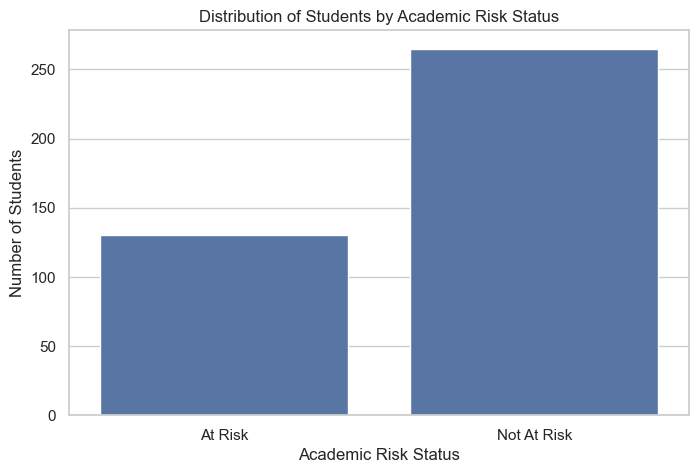

In [24]:
# Visualize academic-risk distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="risk_label"
)

plt.title("Distribution of Students by Academic Risk Status")
plt.xlabel("Academic Risk Status")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The target variable contains 265 students classified as **Not At Risk**, representing 67.09% of the dataset, while 130 students are classified as **At Risk**, representing 32.91%.

The target distribution is moderately imbalanced because the Not At Risk group is approximately twice the size of the At Risk group. However, the At Risk class still contains a substantial number of observations, making classification feasible.

Since identifying students who are genuinely at risk is important for academic intervention, model evaluation will not rely on accuracy alone. Precision, recall, F1-score, and the confusion matrix will also be considered, with particular attention to recall for the At Risk class.

### Insight

Approximately one-third of the students in the dataset are classified as academically at risk under the defined threshold. This indicates that the dataset contains a meaningful group of students requiring further investigation.

The subsequent exploratory analysis will examine whether academic risk is associated with factors such as previous grades, absences, previous failures, study time, educational support, and other student characteristics.

# 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of academic performance and investigate relationships between student characteristics and academic risk.

The analysis focuses on academic grades, absences, previous failures, study time, educational support, and other relevant characteristics.

Visualizations are used to identify patterns, differences, trends, and potential predictors of academic risk before building the machine learning models.

## 8.1 Academic Performance Analysis

The variables `G1`, `G2`, and `G3` represent first-period, second-period, and final grades respectively.

These variables provide information about students' academic progression throughout the course.

In [25]:
# Summary statistics for academic grades

grade_summary = data[["G1", "G2", "G3"]].describe().T

grade_summary

,count,mean,std,min,25%,50%,75%,max
G1,395.0,10.908861,3.319195,3.0,8.0,11.0,13.0,19.0
G2,395.0,10.713924,3.761505,0.0,9.0,11.0,13.0,19.0
G3,395.0,10.415190,4.581443,0.0,8.0,11.0,14.0,20.0


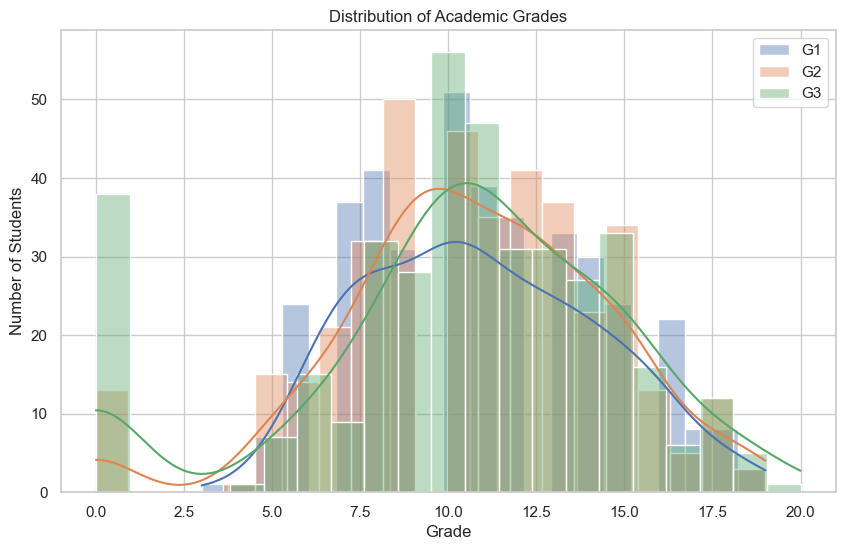

In [26]:
# Visualize the distributions of G1, G2 and G3

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x="G1",
    bins=21,
    kde=True,
    label="G1",
    alpha=0.4
)

sns.histplot(
    data=data,
    x="G2",
    bins=21,
    kde=True,
    label="G2",
    alpha=0.4
)

sns.histplot(
    data=data,
    x="G3",
    bins=21,
    kde=True,
    label="G3",
    alpha=0.4
)

plt.title("Distribution of Academic Grades")
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.legend()

plt.show()

### Interpretation

The distributions of G1, G2, and G3 show that student grades are concentrated mainly within the middle range of the 0–20 grading scale. G1 appears to have a relatively wider distribution toward lower grades, while G2 and G3 show greater concentration around the middle-to-upper grade range.

The three distributions overlap considerably, indicating that students' academic performance across the assessment periods follows related patterns. A noticeable number of observations occur at a final grade of 0, which requires further investigation because such values may represent very poor performance or other circumstances recorded by the dataset.

Further analysis using correlation and scatter plots will be performed to determine how strongly earlier grades are associated with final academic performance.

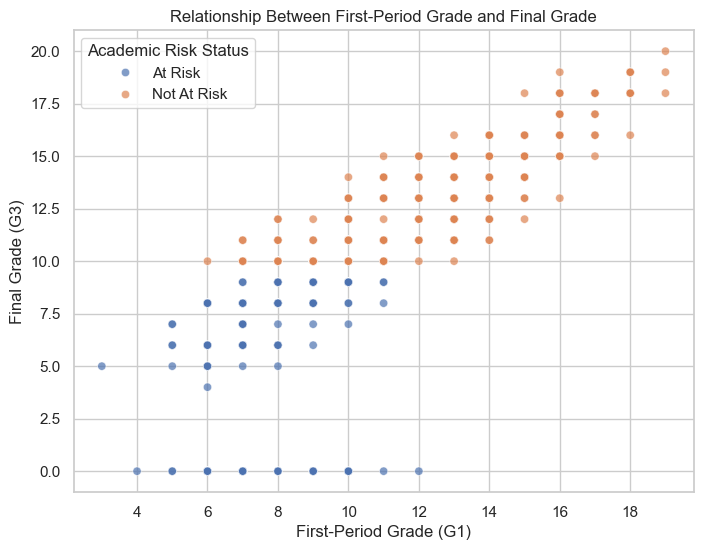

In [27]:
# Relationship between first-period grade and final grade

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data,
    x="G1",
    y="G3",
    hue="risk_label",
    alpha=0.7
)

plt.title("Relationship Between First-Period Grade and Final Grade")
plt.xlabel("First-Period Grade (G1)")
plt.ylabel("Final Grade (G3)")
plt.legend(title="Academic Risk Status")

plt.show()

### Interpretation

The scatter plot shows a clear positive relationship between first-period grade (`G1`) and final grade (`G3`). Students with higher G1 values generally tend to achieve higher G3 values.

The plot also shows a clear separation between the two academic-risk groups. Most students classified as **At Risk** are concentrated in the lower G1 and G3 ranges, while **Not At Risk** students are predominantly located in the higher grade ranges.

An important observation is that several students have a final grade of 0, including students with different G1 values. These observations contribute to the lower end of the G3 distribution and will be retained because they are valid values recorded in the dataset rather than being automatically treated as missing values.

Overall, the visualization suggests that first-period academic performance may be an important early indicator of final academic performance and academic-risk status. This relationship will be quantified using correlation analysis and later evaluated through machine learning models.

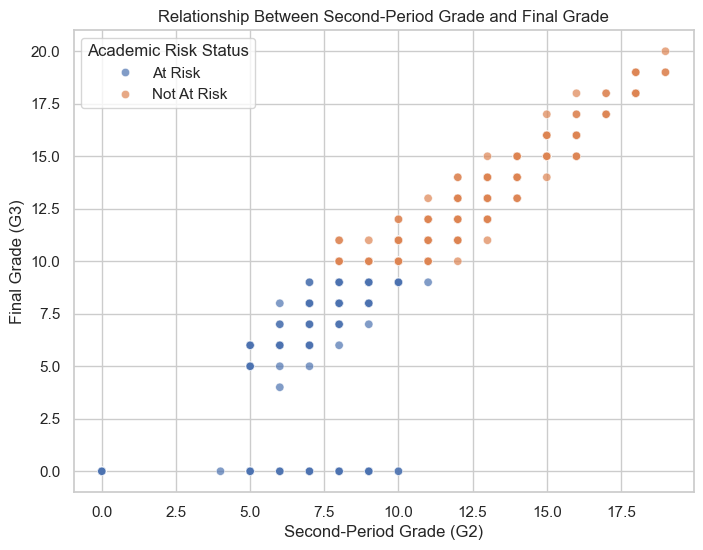

In [28]:
# Relationship between second-period grade and final grade

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data,
    x="G2",
    y="G3",
    hue="risk_label",
    alpha=0.7
)

plt.title("Relationship Between Second-Period Grade and Final Grade")
plt.xlabel("Second-Period Grade (G2)")
plt.ylabel("Final Grade (G3)")
plt.legend(title="Academic Risk Status")

plt.show()

### Interpretation

The scatter plot examines whether second-period performance (`G2`) is associated with final academic performance (`G3`).

A strong positive relationship would indicate that students performing well during the second period generally achieve higher final grades, while students with lower G2 values may have a higher likelihood of being classified as academically at risk.

The strength of this relationship will be quantified using correlation analysis.

In [29]:
# Calculate correlations among academic grades

grade_correlations = data[["G1", "G2", "G3"]].corr()

grade_correlations

,G1,G2,G3
G1,1.000000,0.852118,0.801468
G2,0.852118,1.000000,0.904868
G3,0.801468,0.904868,1.000000


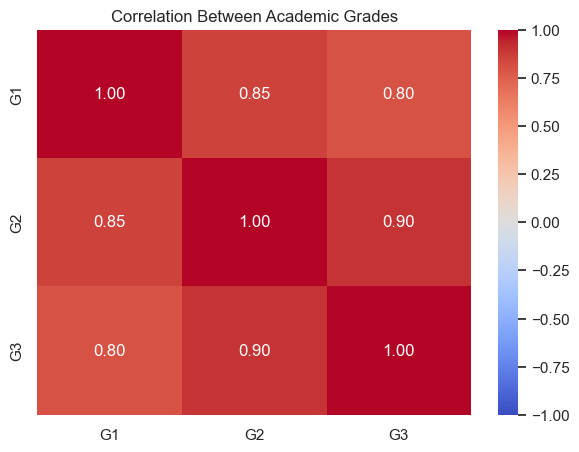

In [30]:
# Visualize correlations among academic grades

plt.figure(figsize=(7, 5))

sns.heatmap(
    grade_correlations,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Academic Grades")

plt.show()

### Interpretation

The correlation matrix shows strong positive relationships among the three academic grades.

- `G1` and `G2` have a correlation of **0.85**, indicating a strong positive relationship between first-period and second-period performance.
- `G1` and `G3` have a correlation of **0.80**, indicating that first-period performance is strongly associated with final academic performance.
- `G2` and `G3` have the strongest relationship, with a correlation of **0.90**. This indicates that second-period performance is very strongly associated with final academic performance.

The results suggest that previous academic performance, particularly `G2`, may provide valuable information for identifying students who are likely to experience poor final academic outcomes.

From an early-warning perspective, `G1` and `G2` are useful predictor candidates because they are available before the final grade (`G3`) is known. However, correlation represents association and does not establish causation.

The strong relationship between `G2` and `G3` will be considered carefully during model development because the objective is to predict academic risk before the final outcome is available.

## 8.2 Attendance-Related Analysis

The dataset contains an `absences` variable representing the number of school absences.

Since a direct attendance percentage is not available, the number of absences is used as an attendance-related indicator. The analysis investigates whether absence patterns differ across students with different levels of academic performance and academic risk.

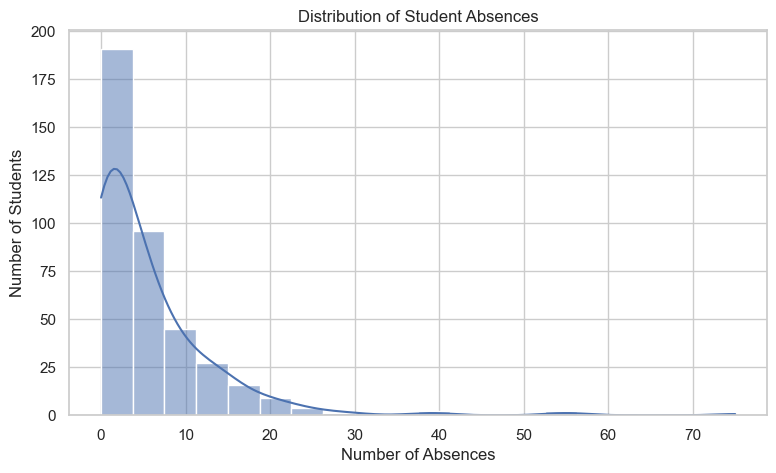

In [31]:
# Distribution of student absences

plt.figure(figsize=(9, 5))

sns.histplot(
    data=data,
    x="absences",
    bins=20,
    kde=True
)

plt.title("Distribution of Student Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Number of Students")

plt.show()

### Interpretation

The distribution of student absences is strongly right-skewed. Most students have relatively low numbers of absences, while a smaller group of students records substantially higher absence counts.

The long right tail indicates that a few students have considerably more absences than the majority of the dataset. These higher-absence observations are important for academic-risk analysis because frequent absence may be associated with reduced academic engagement.

However, the distribution alone does not establish that high absenteeism leads to poor academic performance. The relationship between absences, final grade, and academic-risk status will therefore be examined using additional visualizations and statistical summaries.

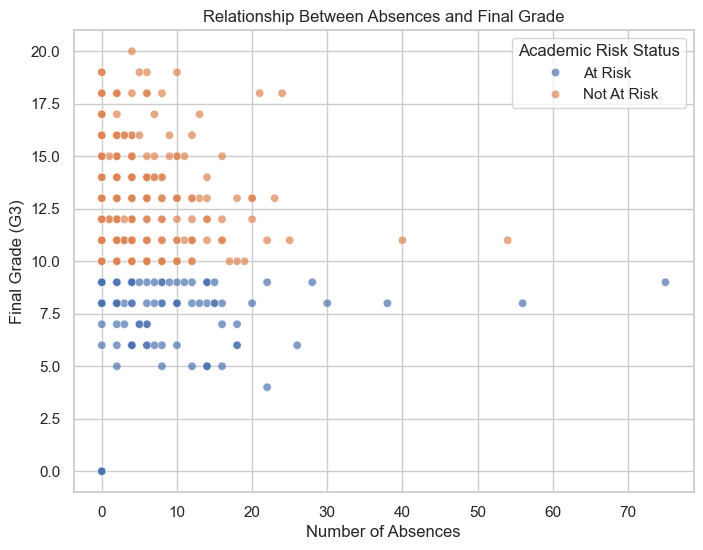

In [32]:
# Relationship between absences and final grade

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=data,
    x="absences",
    y="G3",
    hue="risk_label",
    alpha=0.7
)

plt.title("Relationship Between Absences and Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.legend(title="Academic Risk Status")

plt.show()

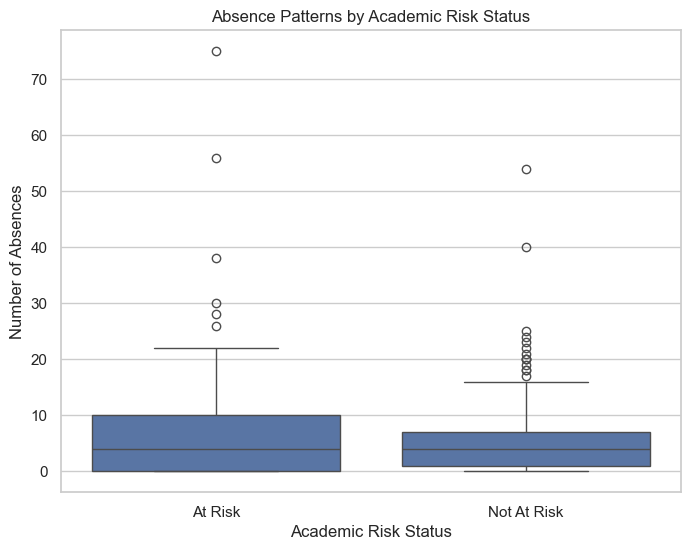

In [33]:
# Compare absences between academic-risk groups

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="risk_label",
    y="absences"
)

plt.title("Absence Patterns by Academic Risk Status")
plt.xlabel("Academic Risk Status")
plt.ylabel("Number of Absences")

plt.show()

In [34]:
# Statistical comparison of absences by academic-risk status

absence_summary = (
    data.groupby("risk_label")["absences"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

absence_summary

,count,mean,median,std,min,max
risk_label,,,,,,
At Risk,130,6.76,4.0,10.48,0,75
Not At Risk,265,5.19,4.0,6.41,0,54


### Interpretation

The absence statistics and boxplot are used to compare attendance-related patterns between At Risk and Not At Risk students.

Differences in the mean, median, spread, and distribution of absences may indicate whether absenteeism is associated with academic risk. However, the analysis will distinguish between association and causation; a difference in absence levels does not by itself establish that absenteeism causes poor academic performance.

## 8.3 Previous Academic Failures

The `failures` variable represents the number of previous class failures.

Previous academic failures are an important indicator of prior academic difficulty. Therefore, this variable is analyzed to determine whether students with a history of failures are more likely to have lower final grades or be classified as academically at risk.

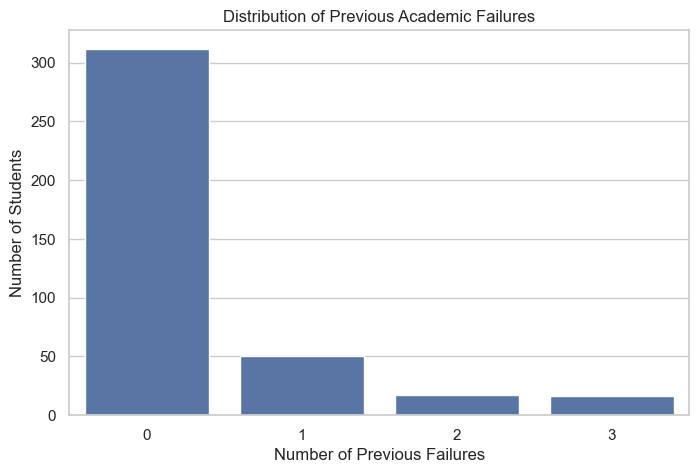

In [35]:
# Distribution of previous academic failures

plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="failures"
)

plt.title("Distribution of Previous Academic Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()

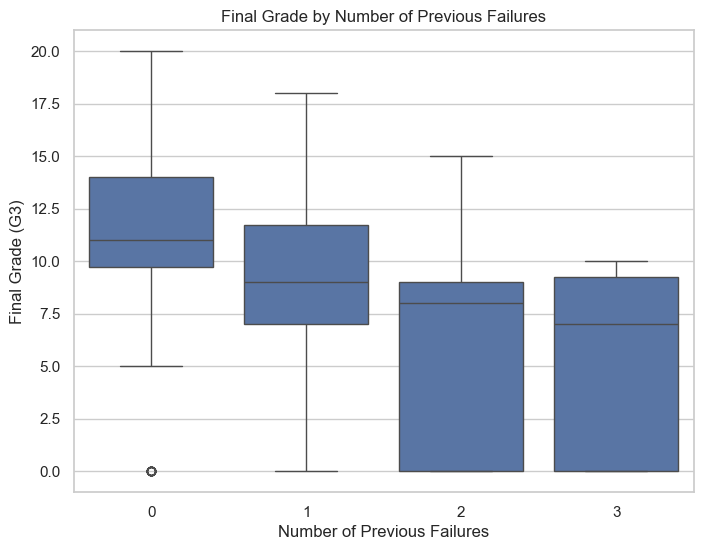

In [36]:
# Final grade by number of previous failures

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="failures",
    y="G3"
)

plt.title("Final Grade by Number of Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Final Grade (G3)")

plt.show()

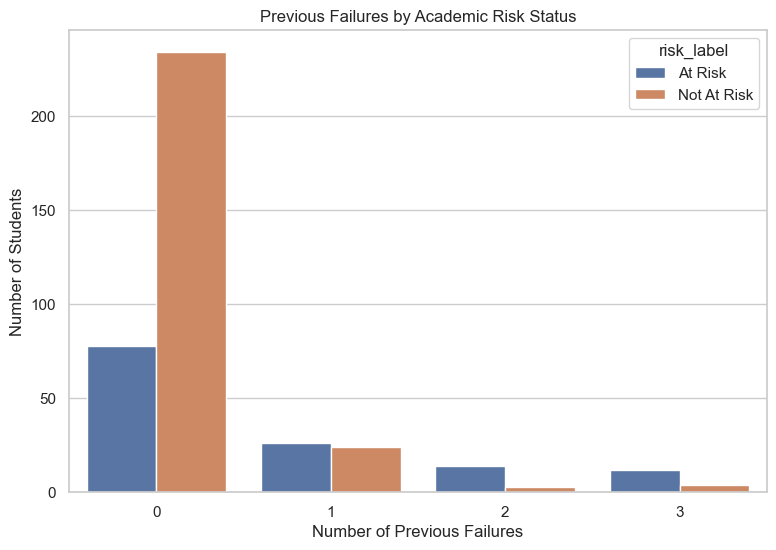

In [37]:
# Previous failures by academic-risk status

plt.figure(figsize=(9, 6))

sns.countplot(
    data=data,
    x="failures",
    hue="risk_label"
)

plt.title("Previous Failures by Academic Risk Status")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()

In [38]:
# Statistical summary of previous failures by risk status

failure_summary = (
    data.groupby("risk_label")["failures"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

failure_summary

,count,mean,median,std,min,max
risk_label,,,,,,
At Risk,130,0.69,0.0,0.99,0,3
Not At Risk,265,0.16,0.0,0.50,0,3


### Interpretation

The distribution of previous failures is examined to understand the academic history of students.

The boxplot and risk-group comparison help determine whether students with a greater number of previous failures tend to have lower final grades or a higher proportion of academic-risk classifications.

If a clear difference is observed, previous failures may represent an important early-warning indicator for academic intervention.

## 8.4 Study Time and Academic Performance

The `studytime` variable represents weekly study time using four categories:

- 1 – Less than 2 hours
- 2 – 2 to 5 hours
- 3 – 5 to 10 hours
- 4 – More than 10 hours

The variable is analyzed to investigate whether study behavior is associated with final academic performance and academic risk.

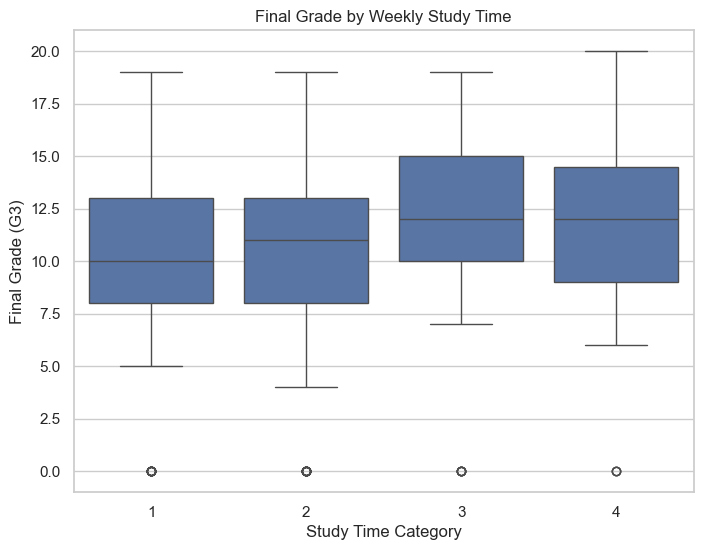

In [39]:
# Final grade by weekly study time

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="studytime",
    y="G3"
)

plt.title("Final Grade by Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade (G3)")

plt.show()

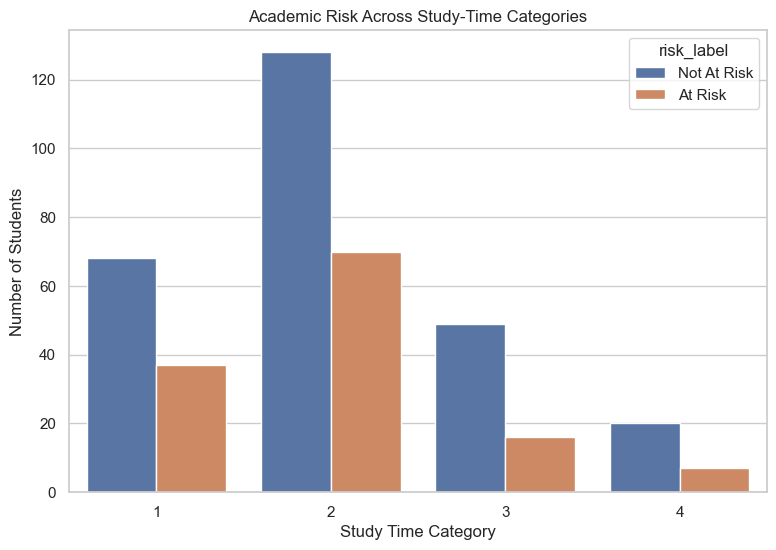

In [40]:
# Academic risk across study-time categories

plt.figure(figsize=(9, 6))

sns.countplot(
    data=data,
    x="studytime",
    hue="risk_label"
)

plt.title("Academic Risk Across Study-Time Categories")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

In [41]:
# Compare academic performance and risk rate by study time

studytime_summary = (
    data.groupby("studytime")
    .agg(
        Student_Count=("G3", "count"),
        Average_G3=("G3", "mean"),
        Average_Absences=("absences", "mean"),
        Average_Failures=("failures", "mean"),
        Risk_Rate=("probation_status", "mean")
    )
)

studytime_summary["Risk_Rate"] = (
    studytime_summary["Risk_Rate"] * 100
).round(2)

studytime_summary.round(2)

,Student_Count,Average_G3,Average_Absences,Average_Failures,Risk_Rate
studytime,,,,,
1,105,10.05,5.76,0.52,35.24
2,198,10.17,6.28,0.31,35.35
3,65,11.40,4.54,0.23,24.62
4,27,11.26,4.15,0.04,25.93


### Interpretation

The study-time analysis shows differences in academic performance and academic-risk rates across the four study-time categories.

Students in study-time category 1 had an average final grade of 10.05 and an academic-risk rate of 35.24%, while category 2 had a similar average grade of 10.17 and the highest observed risk rate of 35.35%.

Students in category 3 had a higher average final grade of 11.40 and a lower risk rate of 24.62%. Category 4 also showed relatively strong academic performance, with an average final grade of 11.26 and a risk rate of 25.93%.

The higher study-time groups also showed lower average previous failures and lower average absence levels. However, categories 3 and 4 contain substantially fewer students than categories 1 and 2. Therefore, these differences should be interpreted as observed associations rather than evidence that increased study time directly causes better academic performance.

Overall, the results suggest that study behavior may provide useful contextual information for identifying academic risk, although academic performance and previous academic history appear to require stronger investigation.

## 8.5 Demographic and Student Characteristics

Academic performance may vary across different student characteristics. Therefore, selected demographic and personal variables are analyzed to identify whether academic-risk patterns differ across student groups.

The analysis focuses on variables such as sex, school, age, address type, and higher-education aspiration.

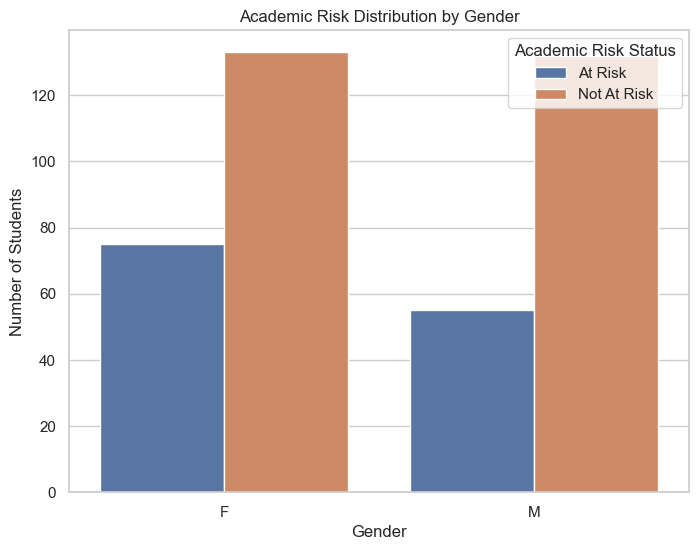

In [42]:
# Academic risk distribution by gender

plt.figure(figsize=(8, 6))

sns.countplot(
    data=data,
    x="sex",
    hue="risk_label"
)

plt.title("Academic Risk Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.legend(title="Academic Risk Status")

plt.show()

In [43]:
# Calculate academic-risk rate by gender

gender_risk = (
    data.groupby("sex")["probation_status"]
    .agg(["count", "mean"])
)

gender_risk["Risk_Rate"] = (
    gender_risk["mean"] * 100
).round(2)

gender_risk = gender_risk.drop(columns="mean")

gender_risk

,count,Risk_Rate
sex,,
F,208,36.06
M,187,29.41


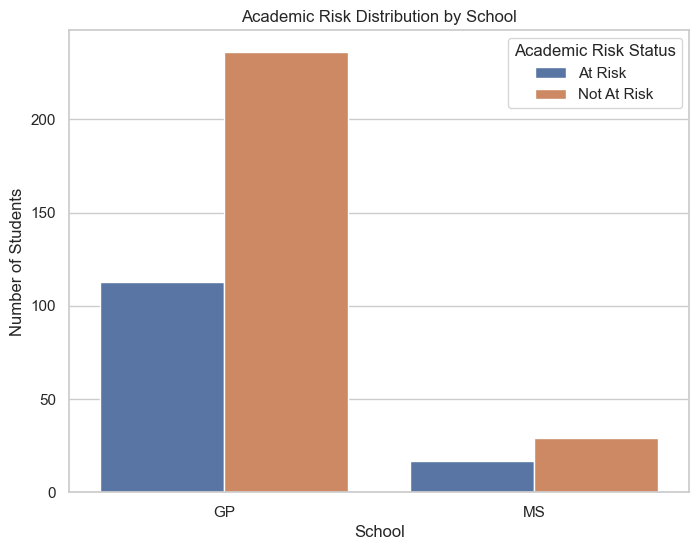

In [44]:
# Academic risk distribution by school

plt.figure(figsize=(8, 6))

sns.countplot(
    data=data,
    x="school",
    hue="risk_label"
)

plt.title("Academic Risk Distribution by School")
plt.xlabel("School")
plt.ylabel("Number of Students")
plt.legend(title="Academic Risk Status")

plt.show()

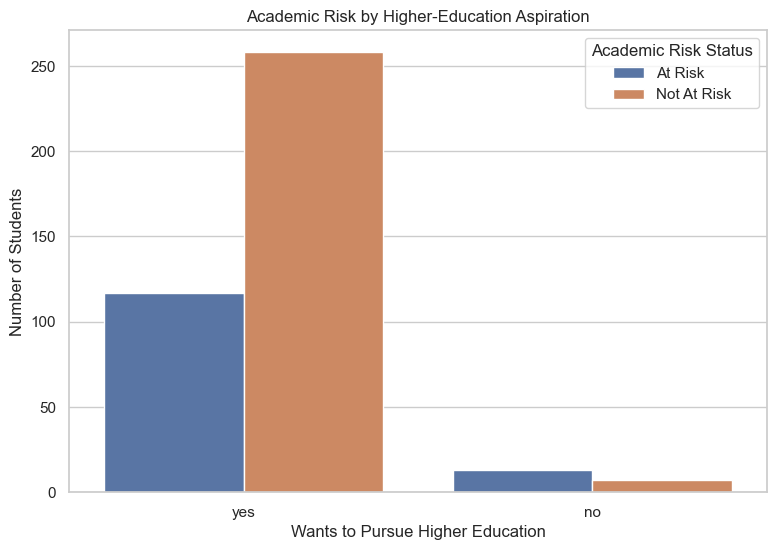

In [45]:
# Academic risk by higher-education aspiration

plt.figure(figsize=(9, 6))

sns.countplot(
    data=data,
    x="higher",
    hue="risk_label"
)

plt.title("Academic Risk by Higher-Education Aspiration")
plt.xlabel("Wants to Pursue Higher Education")
plt.ylabel("Number of Students")
plt.legend(title="Academic Risk Status")

plt.show()

In [46]:
# Calculate risk rate based on higher-education aspiration

higher_risk = (
    data.groupby("higher")["probation_status"]
    .agg(["count", "mean"])
)

higher_risk["Risk_Rate"] = (
    higher_risk["mean"] * 100
).round(2)

higher_risk = higher_risk.drop(columns="mean")

higher_risk

,count,Risk_Rate
higher,,
no,20,65.0
yes,375,31.2


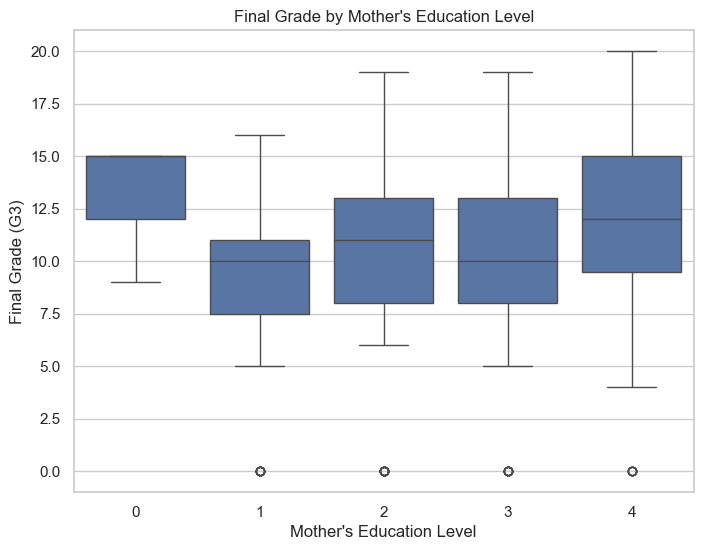

In [47]:
# Final grade by mother's education level

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Medu",
    y="G3"
)

plt.title("Final Grade by Mother's Education Level")
plt.xlabel("Mother's Education Level")
plt.ylabel("Final Grade (G3)")

plt.show()

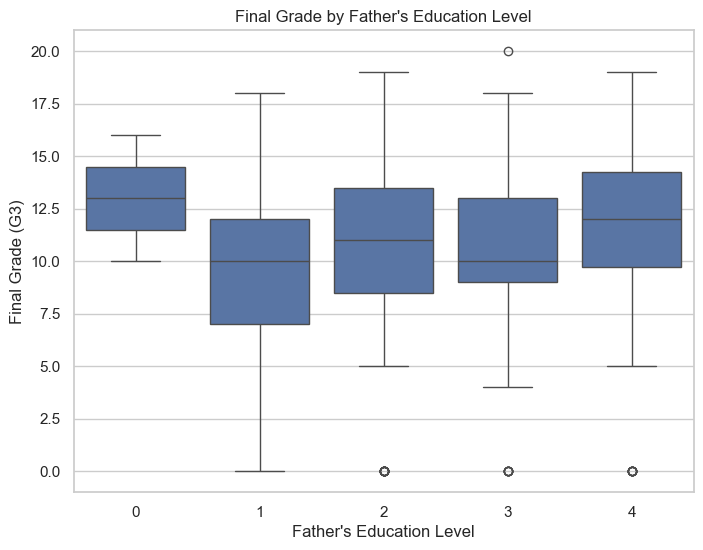

In [48]:
# Final grade by father's education level

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data,
    x="Fedu",
    y="G3"
)

plt.title("Final Grade by Father's Education Level")
plt.xlabel("Father's Education Level")
plt.ylabel("Final Grade (G3)")

plt.show()

## 8.6 Educational Support Analysis

The dataset contains variables indicating whether students receive additional educational support from the school (`schoolsup`) or family (`famsup`).

These variables are analyzed to understand whether academic-risk patterns differ between students receiving support and those who do not.

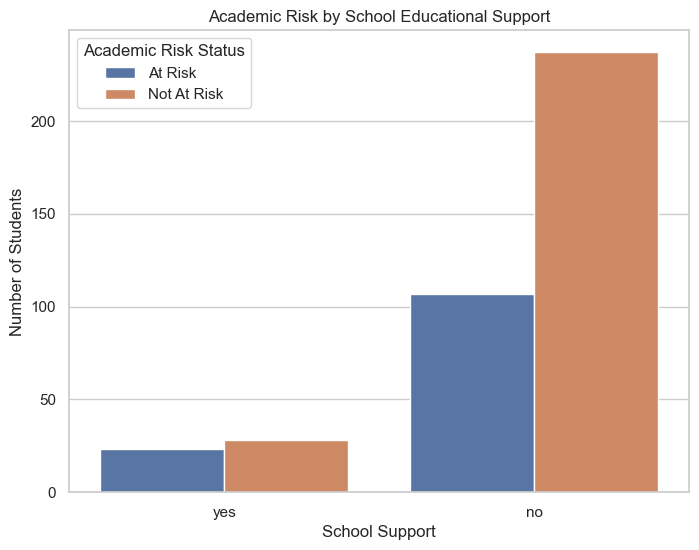

In [49]:
# Academic risk by school educational support

plt.figure(figsize=(8, 6))

sns.countplot(
    data=data,
    x="schoolsup",
    hue="risk_label"
)

plt.title("Academic Risk by School Educational Support")
plt.xlabel("School Support")
plt.ylabel("Number of Students")
plt.legend(title="Academic Risk Status")

plt.show()

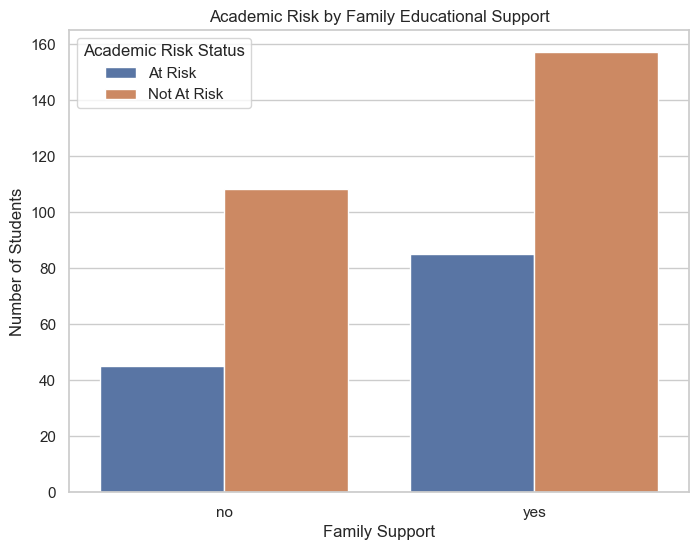

In [50]:
# Academic risk by family educational support

plt.figure(figsize=(8, 6))

sns.countplot(
    data=data,
    x="famsup",
    hue="risk_label"
)

plt.title("Academic Risk by Family Educational Support")
plt.xlabel("Family Support")
plt.ylabel("Number of Students")
plt.legend(title="Academic Risk Status")

plt.show()

In [51]:
# Compare academic performance and risk based on school support

school_support_summary = (
    data.groupby("schoolsup")
    .agg(
        Student_Count=("G3", "count"),
        Average_G3=("G3", "mean"),
        Average_Absences=("absences", "mean"),
        Average_Failures=("failures", "mean"),
        Risk_Rate=("probation_status", "mean")
    )
)

school_support_summary["Risk_Rate"] = (
    school_support_summary["Risk_Rate"] * 100
).round(2)

school_support_summary.round(2)

,Student_Count,Average_G3,Average_Absences,Average_Failures,Risk_Rate
schoolsup,,,,,
no,344,10.56,5.64,0.33,31.1
yes,51,9.43,6.18,0.33,45.1


## 8.7 Overall Correlation Analysis

Correlation analysis is performed on the major numerical variables to identify relationships that may be relevant to academic performance and academic risk.

The analysis includes academic grades, absences, previous failures, study time, parental education, and selected student-behavior variables.

Correlation measures association and does not establish causation.

In [52]:
# Select important numerical variables for correlation analysis

correlation_features = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2",
    "G3"
]

correlation_matrix = data[correlation_features].corr()

correlation_matrix.round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.00,-0.16,-0.16,0.07,-0.00,0.24,0.05,0.02,0.13,0.13,0.12,-0.06,0.18,-0.06,-0.14,-0.16
Medu,-0.16,1.00,0.62,-0.17,0.06,-0.24,-0.00,0.03,0.06,0.02,-0.05,-0.05,0.10,0.21,0.22,0.22
Fedu,-0.16,0.62,1.00,-0.16,-0.01,-0.25,-0.00,-0.01,0.04,0.00,-0.01,0.01,0.02,0.19,0.16,0.15
traveltime,0.07,-0.17,-0.16,1.00,-0.10,0.09,-0.02,-0.02,0.03,0.14,0.13,0.01,-0.01,-0.09,-0.15,-0.12
studytime,-0.00,0.06,-0.01,-0.10,1.00,-0.17,0.04,-0.14,-0.06,-0.20,-0.25,-0.08,-0.06,0.16,0.14,0.10
failures,0.24,-0.24,-0.25,0.09,-0.17,1.00,-0.04,0.09,0.12,0.14,0.14,0.07,0.06,-0.35,-0.36,-0.36
famrel,0.05,-0.00,-0.00,-0.02,0.04,-0.04,1.00,0.15,0.06,-0.08,-0.11,0.09,-0.04,0.02,-0.02,0.05
freetime,0.02,0.03,-0.01,-0.02,-0.14,0.09,0.15,1.00,0.29,0.21,0.15,0.08,-0.06,0.01,-0.01,0.01
goout,0.13,0.06,0.04,0.03,-0.06,0.12,0.06,0.29,1.00,0.27,0.42,-0.01,0.04,-0.15,-0.16,-0.13
Dalc,0.13,0.02,0.00,0.14,-0.20,0.14,-0.08,0.21,0.27,1.00,0.65,0.08,0.11,-0.09,-0.06,-0.05


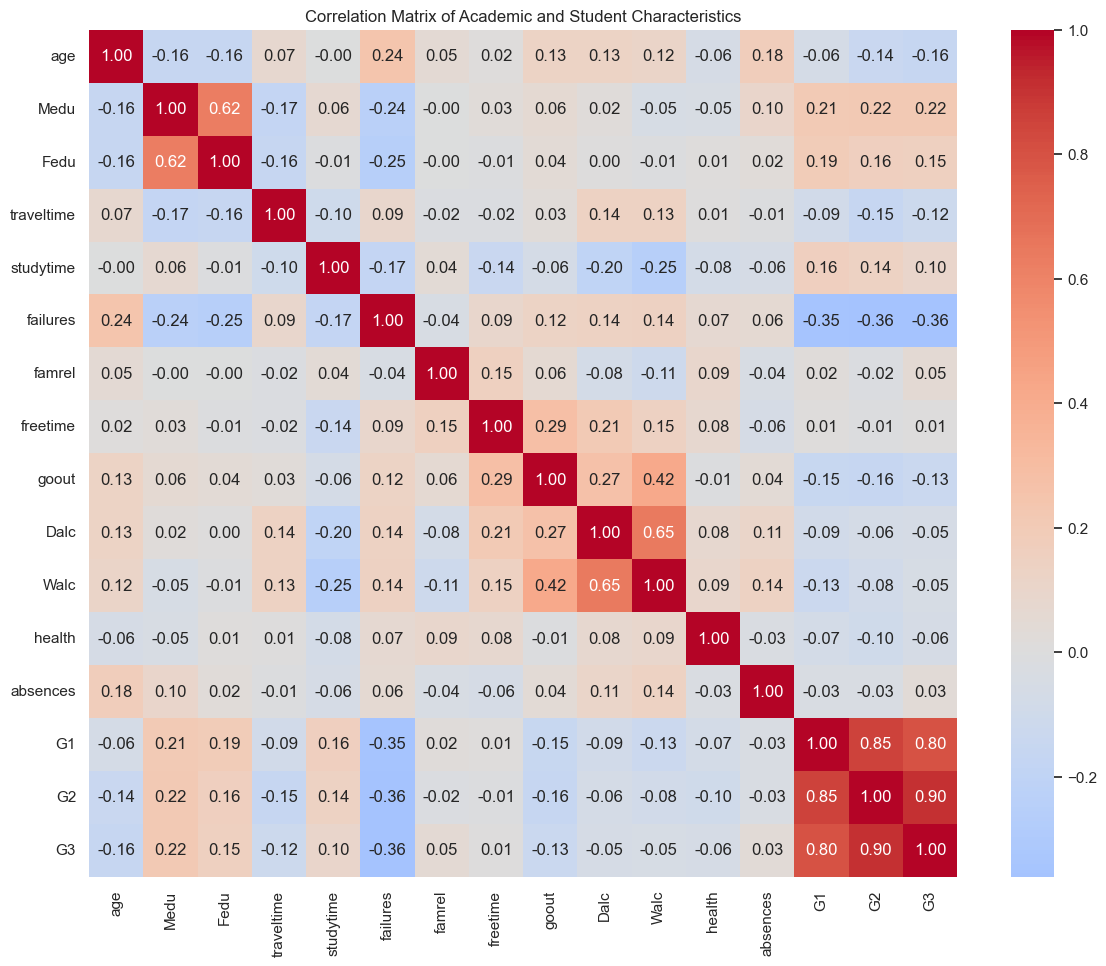

In [53]:
# Visualize the overall correlation matrix

plt.figure(figsize=(14, 11))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Academic and Student Characteristics")

plt.show()

In [54]:
# Identify variables most strongly associated with final grade

g3_correlations = (
    correlation_matrix["G3"]
    .drop("G3")
    .sort_values(key=abs, ascending=False)
)

g3_correlations.round(3)

G2            0.905
G1            0.801
failures     -0.360
Medu          0.217
age          -0.162
Fedu          0.152
goout        -0.133
traveltime   -0.117
studytime     0.098
health       -0.061
Dalc         -0.055
Walc         -0.052
famrel        0.051
absences      0.034
freetime      0.011
Name: G3, dtype: float64

### Interpretation

The correlation analysis identifies previous academic performance as the strongest numerical factor associated with final academic performance.

The strongest positive relationship is observed between `G2` and `G3`, with a correlation coefficient of **0.905**. This indicates a very strong association between second-period and final grades. `G1` also shows a strong positive relationship with `G3`, with a correlation of **0.801**.

The `failures` variable has a moderate negative correlation with `G3` of **-0.360**, indicating that students with more previous academic failures tend to have lower final grades.

Parental education variables show relatively weak positive associations with final grades, while variables such as age, going out, and travel time have weak negative relationships.

Interestingly, `absences` have a very weak linear correlation with `G3` of only **0.034**. Therefore, absence count alone does not show a strong linear relationship with final grade in this dataset. However, this does not imply that attendance-related behavior is completely irrelevant, because machine learning models may identify nonlinear relationships or interactions between variables.

Overall, the correlation analysis suggests that previous academic performance and previous failures are particularly important variables to investigate during predictive modeling.

# 9. Feature Engineering and Machine Learning Preparation

The exploratory analysis identified several variables that may be useful for predicting academic risk.

Before developing the classification models, the dataset must be transformed into predictor variables (`X`) and a target variable (`y`).

The target variable is `probation_status`, where:

- `0` = Not At Risk
- `1` = At Risk

The final grade (`G3`) was used to construct the target variable but will not be used as a predictor. This prevents target leakage because the final grade directly determines the target class.

Previous assessment grades (`G1` and `G2`) are retained because they represent academic information available before the final outcome.

In [55]:
# Create derived academic features using information available before G3

data["previous_grade_average"] = (data["G1"] + data["G2"]) / 2

data["grade_trend"] = data["G2"] - data["G1"]

data[[
    "G1",
    "G2",
    "previous_grade_average",
    "grade_trend",
    "G3",
    "probation_status"
]].head(10)

,G1,G2,previous_grade_average,grade_trend,G3,probation_status
0,5,6,5.5,1,6,1
1,5,5,5.0,0,6,1
2,7,8,7.5,1,10,0
3,15,14,14.5,-1,15,0
4,6,10,8.0,4,10,0
5,15,15,15.0,0,15,0
6,12,12,12.0,0,11,0
7,6,5,5.5,-1,6,1
8,16,18,17.0,2,19,0
9,14,15,14.5,1,15,0


### Feature Engineering Interpretation

Two derived academic features were created using information from the first and second assessment periods.

- **Previous Grade Average** is calculated as `(G1 + G2) / 2` and represents the student's average performance across the two previous assessment periods.
- **Grade Trend** is calculated as `G2 - G1` and represents the change in academic performance between the first and second assessment periods.

A positive `grade_trend` indicates improvement from G1 to G2, a value of zero indicates no change, and a negative value indicates a decline in performance.

For example, a student with G1 = 5 and G2 = 6 has a previous-grade average of 5.5 and a grade trend of +1, indicating an improvement in performance.

The variables `G3` and `probation_status` are displayed in the verification table only to confirm the feature calculations and target values. They will not be included as predictor variables in the machine learning models. This prevents target leakage because `G3` is directly related to the definition of the academic-risk target.

In [56]:
# Define target variable

y = data["probation_status"]

# Columns that must not be used as predictors
excluded_columns = [
    "G3",
    "probation_status",
    "risk_label"
]

# Create predictor dataset
X = data.drop(columns=excluded_columns)

print("Predictor dataset shape:", X.shape)
print("Target shape:", y.shape)

Predictor dataset shape: (395, 34)
Target shape: (395,)


In [57]:
# Verify predictor columns and check for target leakage

print("Number of predictor columns:", len(X.columns))
print("\nPredictor columns:\n")

for i, column in enumerate(X.columns, start=1):
    print(f"{i}. {column}")

print("\nChecking for excluded columns:")

for column in excluded_columns:
    print(f"{column}: {'Present' if column in X.columns else 'Not Present'}")

Number of predictor columns: 34

Predictor columns:

1. school
2. sex
3. age
4. address
5. famsize
6. Pstatus
7. Medu
8. Fedu
9. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences
31. G1
32. G2
33. previous_grade_average
34. grade_trend

Checking for excluded columns:
G3: Not Present
probation_status: Not Present
risk_label: Not Present


In [58]:
# Identify numerical and categorical predictor variables

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))

print("\nNumerical features:")
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 17

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'previous_grade_average', 'grade_trend']

Number of categorical features: 17

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [59]:
# Verify target distribution before model training

print("Target distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(2))

Target distribution:
probation_status
0    265
1    130
Name: count, dtype: int64

Target percentage:
probation_status
0    67.09
1    32.91
Name: proportion, dtype: float64


In [60]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set shape: (316, 34)
Testing set shape: (79, 34)

Training target distribution:
probation_status
0    212
1    104
Name: count, dtype: int64

Testing target distribution:
probation_status
0    53
1    26
Name: count, dtype: int64


In [61]:
# Compare target proportions across the full, training, and testing datasets

distribution_comparison = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True),
    "Training Set": y_train.value_counts(normalize=True),
    "Testing Set": y_test.value_counts(normalize=True)
}) * 100

distribution_comparison.round(2)

,Full Dataset,Training Set,Testing Set
probation_status,,,
0,67.09,67.09,67.09
1,32.91,32.91,32.91


### Train-Test Split Interpretation

The dataset was divided into training and testing subsets using an 80:20 ratio. Stratified sampling was applied to preserve the proportion of At Risk and Not At Risk students in both subsets.

The training data is used to develop the classification models, while the testing data is kept separate for evaluating their performance on unseen student records.

Stratification is particularly important because the target classes are moderately imbalanced.

In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [63]:
# Preprocessing pipeline for Decision Tree

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numeric_features
        )
    ]
)

print("Decision Tree preprocessing pipeline created successfully.")

Decision Tree preprocessing pipeline created successfully.


In [64]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [65]:
# Create Decision Tree pipeline

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

print("Decision Tree pipeline created successfully.")

Decision Tree pipeline created successfully.


In [66]:
# Train the initial Decision Tree model

decision_tree_pipeline.fit(
    X_train,
    y_train
)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [67]:
# Generate predictions on the unseen test data

y_pred_tree = decision_tree_pipeline.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_tree))

Predictions generated successfully.
Number of predictions: 79


In [68]:
# Calculate Decision Tree accuracy

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print(f"Decision Tree Accuracy: {tree_accuracy:.4f}")
print(f"Decision Tree Accuracy: {tree_accuracy * 100:.2f}%")

Decision Tree Accuracy: 0.8861
Decision Tree Accuracy: 88.61%


In [69]:
# Generate the complete classification report

print("Decision Tree Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=[
            "Not At Risk",
            "At Risk"
        ],
        zero_division=0
    )
)

Decision Tree Classification Report

              precision    recall  f1-score   support

 Not At Risk       0.89      0.94      0.92        53
     At Risk       0.87      0.77      0.82        26

    accuracy                           0.89        79
   macro avg       0.88      0.86      0.87        79
weighted avg       0.89      0.89      0.88        79



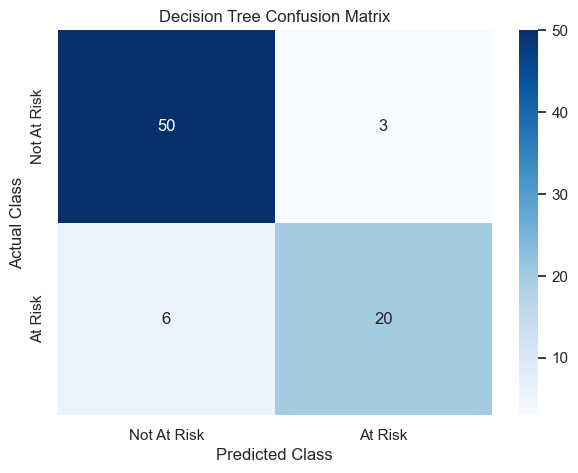

In [70]:
# Create the Decision Tree confusion matrix

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not At Risk",
        "At Risk"
    ],
    yticklabels=[
        "Not At Risk",
        "At Risk"
    ]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [71]:
# Calculate evaluation metrics for the Decision Tree

tree_precision = precision_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_recall = recall_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree,
    zero_division=0
)

tree_auc = roc_auc_score(
    y_test,
    decision_tree_pipeline.predict_proba(X_test)[:, 1]
)

tree_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_auc
    ]
})

tree_metrics["Score"] = tree_metrics["Score"].round(4)

tree_metrics

,Metric,Score
0,Accuracy,0.8861
1,Precision,0.8696
2,Recall,0.7692
3,F1-Score,0.8163
4,ROC-AUC,0.8563


### Decision Tree Evaluation — Interpretation

The initial Decision Tree classifier achieved an overall accuracy of **88.61%** on the unseen test set, indicating that the model correctly classified most of the students.

The model achieved a precision of **86.96%** and a recall of **76.92%** for the **At Risk** class, resulting in an F1-score of **81.63%**. The ROC-AUC score was **85.63%**, indicating good discrimination between At Risk and Not At Risk students.

The confusion matrix provides further insight into the model's predictions. Out of 79 test observations:

- **50 Not At Risk students** were correctly classified as Not At Risk.
- **20 At Risk students** were correctly identified as At Risk.
- **3 Not At Risk students** were incorrectly classified as At Risk.
- **6 At Risk students** were incorrectly classified as Not At Risk.

The recall of 76.92% for the At Risk class is particularly important for this application because the purpose of the model is to identify students who may require academic support. The six false-negative cases represent students who were actually At Risk but were not identified by the model.

Although the initial Decision Tree performs well, there is still scope for improvement, particularly in reducing false negatives and improving recall for the At Risk class. Therefore, the model will be optimized using hyperparameter tuning and cross-validation before comparing it with an SVM classifier.

# 10. Decision Tree Optimization

The initial Decision Tree provides a baseline model for academic-risk prediction. However, a Decision Tree can become overly complex and may overfit the training data.

Hyperparameter tuning is therefore performed to identify a better combination of model parameters.

The main parameters considered include:

- `criterion` — method used to measure the quality of a split.
- `max_depth` — maximum depth of the tree.
- `min_samples_split` — minimum number of observations required to split an internal node.
- `min_samples_leaf` — minimum number of observations required in a leaf node.

Grid search with cross-validation will be used to identify a suitable parameter combination based on F1-score.

In [72]:
from sklearn.model_selection import GridSearchCV

In [73]:
# Define hyperparameters for Decision Tree tuning

param_grid_tree = {
    "classifier__criterion": [
        "gini",
        "entropy"
    ],
    
    "classifier__max_depth": [
        3,
        4,
        5,
        6,
        8,
        None
    ],
    
    "classifier__min_samples_split": [
        2,
        5,
        10
    ],
    
    "classifier__min_samples_leaf": [
        1,
        2,
        4
    ]
}

print("Number of parameter combinations:")

total_combinations = (
    2 * 6 * 3 * 3
)

print(total_combinations)

Number of parameter combinations:
108


In [74]:
# Perform hyperparameter tuning using 5-fold cross-validation

grid_search_tree = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=param_grid_tree,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search_tree.fit(
    X_train,
    y_train
)

print("Grid search completed successfully.")

Grid search completed successfully.


In [75]:
# Display the best Decision Tree parameters

print("Best Decision Tree Parameters:\n")

for parameter, value in grid_search_tree.best_params_.items():
    print(f"{parameter}: {value}")

Best Decision Tree Parameters:

classifier__criterion: entropy
classifier__max_depth: 5
classifier__min_samples_leaf: 4
classifier__min_samples_split: 10


In [76]:
# Display the best cross-validation F1-score

print(
    f"Best Cross-Validation F1-Score: "
    f"{grid_search_tree.best_score_:.4f}"
)

Best Cross-Validation F1-Score: 0.8661


In [77]:
# Store the optimized Decision Tree model

best_tree_model = grid_search_tree.best_estimator_

print("Optimized Decision Tree model created successfully.")

Optimized Decision Tree model created successfully.


In [78]:
# Generate predictions using the optimized Decision Tree

y_pred_tuned_tree = best_tree_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_tuned_tree))

Predictions generated successfully.
Number of predictions: 79


In [79]:
# Calculate accuracy of the optimized Decision Tree

tuned_tree_accuracy = accuracy_score(
    y_test,
    y_pred_tuned_tree
)

print(
    f"Optimized Decision Tree Accuracy: "
    f"{tuned_tree_accuracy:.4f}"
)

print(
    f"Optimized Decision Tree Accuracy: "
    f"{tuned_tree_accuracy * 100:.2f}%"
)

Optimized Decision Tree Accuracy: 0.8734
Optimized Decision Tree Accuracy: 87.34%


In [80]:
# Classification report for optimized Decision Tree

print("Optimized Decision Tree Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_tuned_tree,
        target_names=[
            "Not At Risk",
            "At Risk"
        ],
        zero_division=0
    )
)

Optimized Decision Tree Classification Report

              precision    recall  f1-score   support

 Not At Risk       0.92      0.89      0.90        53
     At Risk       0.79      0.85      0.81        26

    accuracy                           0.87        79
   macro avg       0.85      0.87      0.86        79
weighted avg       0.88      0.87      0.87        79



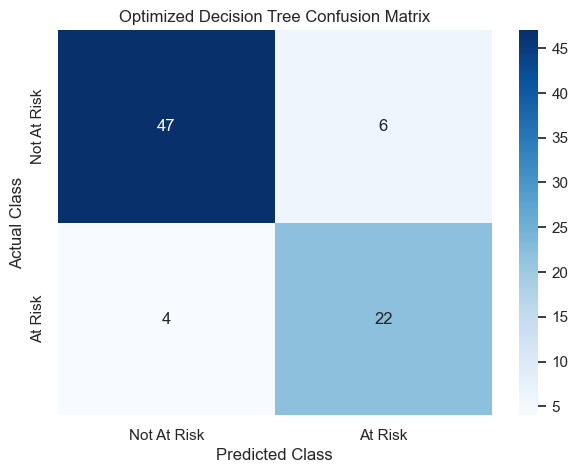

In [81]:
# Confusion Matrix for optimized Decision Tree

cm_tuned_tree = confusion_matrix(
    y_test,
    y_pred_tuned_tree
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tuned_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not At Risk",
        "At Risk"
    ],
    yticklabels=[
        "Not At Risk",
        "At Risk"
    ]
)

plt.title("Optimized Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [82]:
# Calculate all evaluation metrics for the optimized Decision Tree

tuned_tree_precision = precision_score(
    y_test,
    y_pred_tuned_tree,
    zero_division=0
)

tuned_tree_recall = recall_score(
    y_test,
    y_pred_tuned_tree,
    zero_division=0
)

tuned_tree_f1 = f1_score(
    y_test,
    y_pred_tuned_tree,
    zero_division=0
)

tuned_tree_auc = roc_auc_score(
    y_test,
    best_tree_model.predict_proba(X_test)[:, 1]
)

tuned_tree_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        tuned_tree_accuracy,
        tuned_tree_precision,
        tuned_tree_recall,
        tuned_tree_f1,
        tuned_tree_auc
    ]
})

tuned_tree_metrics["Score"] = (
    tuned_tree_metrics["Score"].round(4)
)

tuned_tree_metrics

,Metric,Score
0,Accuracy,0.8734
1,Precision,0.7857
2,Recall,0.8462
3,F1-Score,0.8148
4,ROC-AUC,0.9260


In [83]:
# Compare initial and optimized Decision Tree

tree_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    
    "Initial Decision Tree": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_auc
    ],
    
    "Optimized Decision Tree": [
        tuned_tree_accuracy,
        tuned_tree_precision,
        tuned_tree_recall,
        tuned_tree_f1,
        tuned_tree_auc
    ]
})

tree_comparison.round(4)

,Metric,Initial Decision Tree,Optimized Decision Tree
0,Accuracy,0.8861,0.8734
1,Precision,0.8696,0.7857
2,Recall,0.7692,0.8462
3,F1-Score,0.8163,0.8148
4,ROC-AUC,0.8563,0.9260


In [84]:
# Calculate improvement from initial to optimized Decision Tree

tree_comparison["Improvement"] = (
    tree_comparison["Optimized Decision Tree"]
    - tree_comparison["Initial Decision Tree"]
)

tree_comparison.round(4)

,Metric,Initial Decision Tree,Optimized Decision Tree,Improvement
0,Accuracy,0.8861,0.8734,-0.0127
1,Precision,0.8696,0.7857,-0.0839
2,Recall,0.7692,0.8462,0.0769
3,F1-Score,0.8163,0.8148,-0.0015
4,ROC-AUC,0.8563,0.9260,0.0697


# 11. Feature Importance and Major Predictors

Understanding model performance alone is not sufficient for an academic-risk prediction system. The university also needs to understand which student characteristics contribute most strongly to the predictions.

The optimized Decision Tree provides feature-importance values that indicate how strongly individual encoded features contribute to the model's decision-making process.

Because categorical variables were converted into multiple one-hot encoded variables, feature importance will first be examined at the encoded-feature level and then aggregated to the original dataset variables where appropriate.

In [85]:
# Extract the feature names produced by the preprocessing pipeline

preprocessor = best_tree_model.named_steps["preprocessor"]
tree_classifier = best_tree_model.named_steps["classifier"]

encoded_feature_names = preprocessor.get_feature_names_out()

print("Number of encoded features:", len(encoded_feature_names))

print("\nFirst 20 encoded features:")
print(encoded_feature_names[:20])

Number of encoded features: 60

First 20 encoded features:
['categorical__school_GP' 'categorical__school_MS' 'categorical__sex_F'
 'categorical__sex_M' 'categorical__address_R' 'categorical__address_U'
 'categorical__famsize_GT3' 'categorical__famsize_LE3'
 'categorical__Pstatus_A' 'categorical__Pstatus_T'
 'categorical__Mjob_at_home' 'categorical__Mjob_health'
 'categorical__Mjob_other' 'categorical__Mjob_services'
 'categorical__Mjob_teacher' 'categorical__Fjob_at_home'
 'categorical__Fjob_health' 'categorical__Fjob_other'
 'categorical__Fjob_services' 'categorical__Fjob_teacher']


In [86]:
# Extract feature importance from the optimized Decision Tree

feature_importance = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": tree_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,numerical__G2,0.802813
1,numerical__previous_grade_average,0.050039
2,numerical__grade_trend,0.022565
3,categorical__activities_yes,0.022551
4,numerical__Fedu,0.021813
5,numerical__goout,0.018238
6,numerical__age,0.016481
7,numerical__famrel,0.015760
8,categorical__activities_no,0.014934
9,categorical__famsize_LE3,0.014805


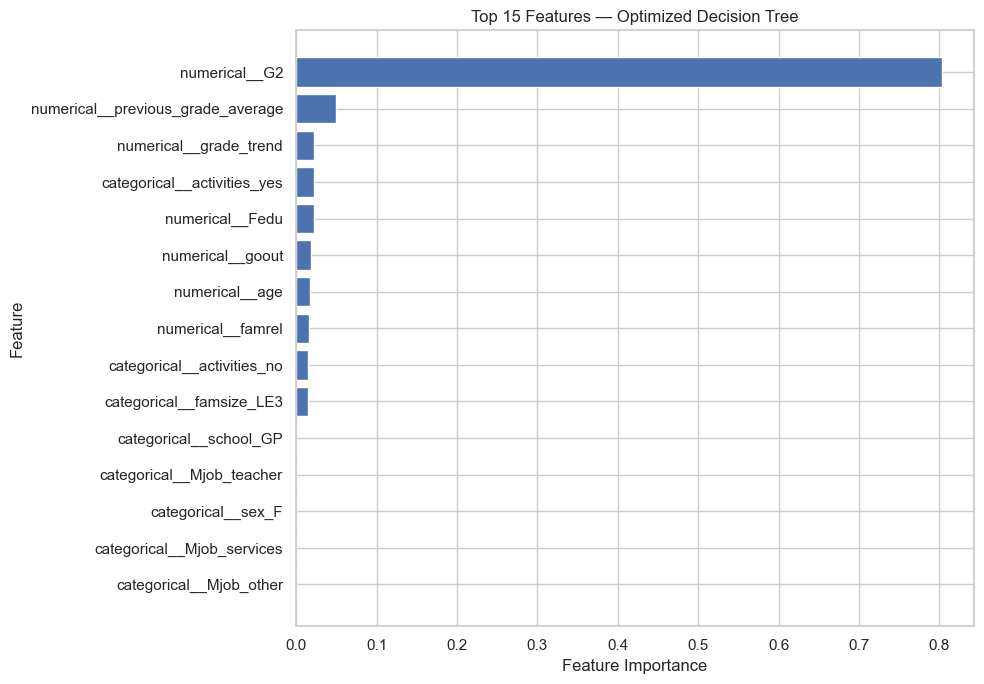

In [87]:
# Visualize the 15 most important encoded features

top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features — Optimized Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Decision Tree Feature Importance — Interpretation

The feature-importance analysis shows that **G2 (second-period grade)** is by far the most influential predictor in the optimized Decision Tree, with an importance value of approximately **0.803**.

This indicates that the student's second-period academic performance provides substantial predictive information about whether the student is classified as At Risk or Not At Risk.

The next important predictors include **previous grade average (0.050)** and **grade trend (0.023)**. These features represent the student's academic performance and change in performance across earlier assessment periods.

Other variables appearing among the important predictors include **participation in extracurricular activities, father's education level, social activity frequency, age, and family relationship quality**. However, their individual importance values are considerably smaller than that of G2.

The dominance of G2 should be interpreted carefully. A high feature-importance value indicates strong predictive usefulness within the model and dataset; it does not establish a causal relationship between the feature and academic probation.

The results also suggest that previous academic performance is particularly useful for identifying students who may require early academic support. This supports the use of continuous academic monitoring rather than waiting until the final academic outcome is available.

In [88]:
# Create a mapping from encoded features back to original variables

def get_original_feature(encoded_name):
    if "__" in encoded_name:
        encoded_name = encoded_name.split("__", 1)[1]
    
    for column in X.columns:
        if encoded_name == column or encoded_name.startswith(column + "_"):
            return column
    
    return encoded_name


feature_importance["Original_Feature"] = (
    feature_importance["Feature"]
    .apply(get_original_feature)
)

aggregated_importance = (
    feature_importance
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

aggregated_importance.head(15)

,Original_Feature,Importance
0,G2,0.802813
1,previous_grade_average,0.050039
2,activities,0.037485
3,grade_trend,0.022565
4,Fedu,0.021813
5,goout,0.018238
6,age,0.016481
7,famrel,0.015760
8,famsize,0.014805
9,Dalc,0.000000


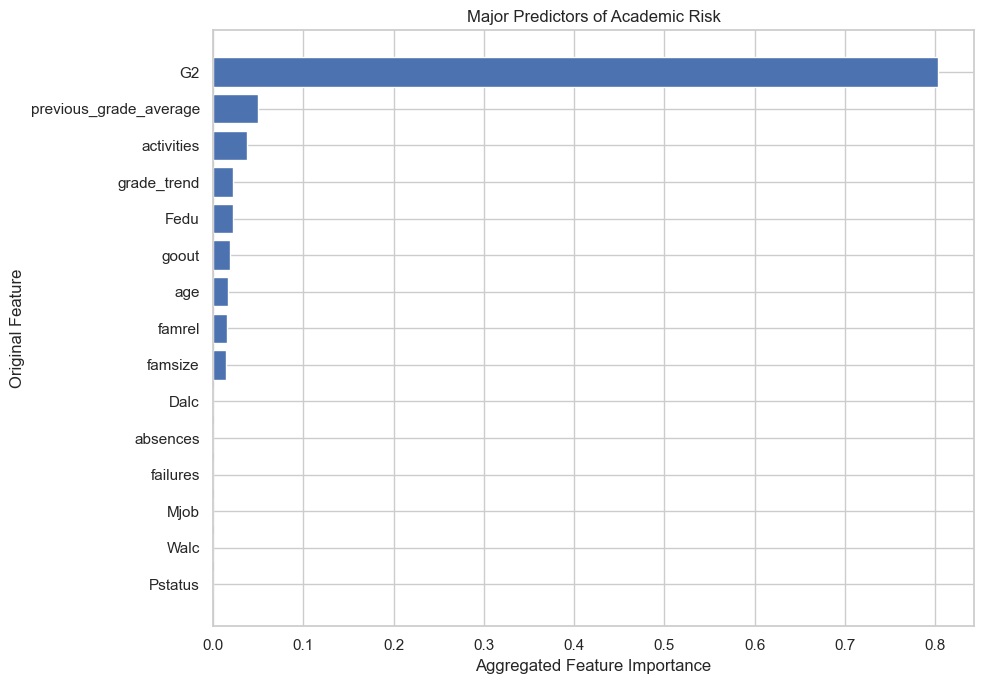

In [89]:
# Visualize the top original predictor variables

top_original_features = (
    aggregated_importance
    .head(15)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_original_features["Original_Feature"],
    top_original_features["Importance"]
)

plt.title("Major Predictors of Academic Risk")
plt.xlabel("Aggregated Feature Importance")
plt.ylabel("Original Feature")

plt.tight_layout()
plt.show()

In [90]:
# Display the ten most important original predictor variables

top_10_predictors = aggregated_importance.head(10).copy()

top_10_predictors["Importance"] = (
    top_10_predictors["Importance"].round(4)
)

top_10_predictors

,Original_Feature,Importance
0,G2,0.8028
1,previous_grade_average,0.0500
2,activities,0.0375
3,grade_trend,0.0226
4,Fedu,0.0218
5,goout,0.0182
6,age,0.0165
7,famrel,0.0158
8,famsize,0.0148
9,Dalc,0.0000


### Major Predictor Analysis — Interpretation

The aggregated feature-importance analysis shows that **G2 (second-period grade)** is the dominant predictor of academic risk, with an importance value of **0.8028**. This is substantially higher than the importance of all other predictors.

The second most important predictor is **previous grade average**, with an importance of **0.0500**. This indicates that a student's previous academic performance provides additional predictive information beyond the individual G2 value.

Other relatively important predictors include **activities (0.0375)**, **grade trend (0.0226)**, **father's education level (Fedu) (0.0218)**, **social activity frequency (goout) (0.0182)**, **age (0.0165)**, **family relationship quality (famrel) (0.0158)**, and **family size (famsize) (0.0148)**.

The results indicate that academic-performance variables are considerably more influential than most demographic and lifestyle variables in this Decision Tree model.

The very high importance of G2 suggests that recent academic performance is highly informative for identifying students who may be at academic risk. Therefore, universities could use earlier assessment results as an early-warning signal and provide support before students reach the final academic outcome.

However, feature importance represents predictive usefulness within the model and dataset; it does not establish that a feature directly causes academic probation. The findings should therefore be interpreted as predictive associations rather than causal relationships.

The zero importance observed for some variables indicates that those variables were not used meaningfully by the optimized Decision Tree for its predictive splits.

In [91]:
from sklearn.inspection import permutation_importance

In [92]:
# Calculate permutation importance on the unseen test set

permutation_result = permutation_importance(
    best_tree_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": permutation_result.importances_mean,
    "Importance_STD": permutation_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        by="Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_importance_df.head(15)

,Feature,Importance_Mean,Importance_STD
0,G2,0.406498,0.063513
1,previous_grade_average,0.024715,0.010991
2,goout,0.002480,0.018253
3,school,0.000000,0.000000
4,sex,0.000000,0.000000
5,address,0.000000,0.000000
6,Fjob,0.000000,0.000000
7,famsize,0.000000,0.000000
8,Pstatus,0.000000,0.000000
9,Medu,0.000000,0.000000


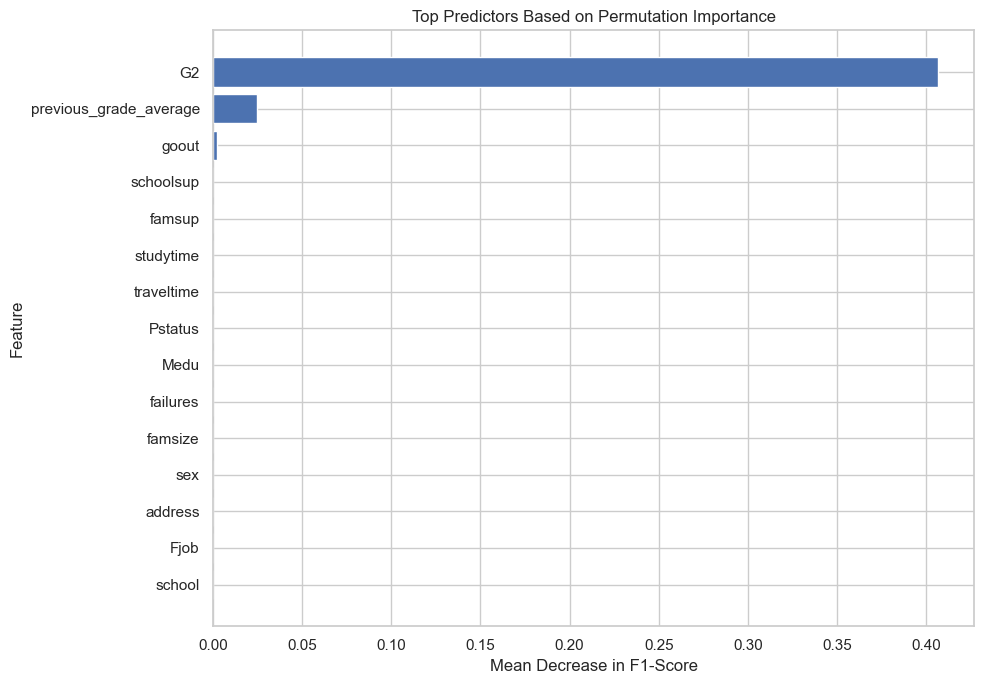

In [93]:
# Visualize the top 15 permutation-importance features

top_permutation = (
    permutation_importance_df
    .head(15)
    .sort_values(
        by="Importance_Mean",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation["Feature"],
    top_permutation["Importance_Mean"]
)

plt.title("Top Predictors Based on Permutation Importance")
plt.xlabel("Mean Decrease in F1-Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 12. Academic Intervention Recommendations

The objective of the predictive system is not merely to classify students but to support timely academic intervention.

Based on the analysis, academic-performance indicators should receive priority in the early-warning process.

### Recommended interventions

1. **Early performance monitoring**

   Students showing weak performance in earlier assessments can be identified before the final academic outcome and referred for academic support.

2. **Academic advising**

   Students classified as At Risk can be referred to academic advisors for individualized academic planning.

3. **Remedial and tutoring support**

   Students with weak academic performance or previous failures can receive subject-specific tutoring, remedial classes, and mentoring.

4. **Progress monitoring**

   Students identified as potentially at risk can be monitored across successive assessments rather than evaluated only at the end of the semester.

5. **Study and engagement support**

   Students showing weaker academic engagement can be encouraged to participate in structured study programs, mentoring, and academic-support activities.

6. **Personalized intervention**

   The model's predictions should support, rather than replace, academic advisors. Final intervention decisions should consider the student's broader academic context.

The feature-importance and permutation-importance results indicate that recent academic performance is particularly informative for prediction. Therefore, an effective intervention system should focus on identifying deterioration in academic performance early enough to provide meaningful support.

### Predictive Modeling Validity and Target Leakage

The final academic grade (G3) was excluded from the predictor variables because it represents the final academic outcome and is directly related to the academic-risk definition.

Including G3 as a predictor would allow the model to use information that would only be known after the student's academic performance has already been determined. This would result in target leakage and would make the model unsuitable as an early-warning system.

The model therefore uses earlier information such as G1, G2, previous-grade average, grade trend, failures, absences, and other student characteristics.

This makes the modeling approach more consistent with the university's objective of identifying potentially At Risk students before they reach the probation threshold.

In [94]:
# Import SVM classifier

from sklearn.svm import SVC

print("SVM classifier imported successfully.")

SVM classifier imported successfully.


In [96]:
# Prepare data specifically for SVM

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify numerical and categorical predictor columns
numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 17
Number of categorical features: 17

Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'previous_grade_average', 'grade_trend']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [97]:
# Create preprocessing pipeline for SVM

svm_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("SVM preprocessing pipeline created successfully.")

SVM preprocessing pipeline created successfully.


In [98]:
# Create the complete SVM pipeline

svm_model = Pipeline(
    steps=[
        (
            "preprocessor",
            svm_preprocessor
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]
)

print("SVM pipeline created successfully.")

SVM pipeline created successfully.


In [99]:
# Train the SVM pipeline

svm_model.fit(
    X_train,
    y_train
)

print("SVM model trained successfully.")

SVM model trained successfully.


In [100]:
# Generate predictions using the trained SVM

y_pred_svm = svm_model.predict(X_test)

print("Number of SVM predictions:", len(y_pred_svm))

Number of SVM predictions: 79


In [101]:
# Calculate SVM accuracy

svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

print(f"SVM Accuracy: {svm_accuracy:.4f}")
print(f"SVM Accuracy: {svm_accuracy * 100:.2f}%")

SVM Accuracy: 0.8987
SVM Accuracy: 89.87%


In [102]:
# Generate SVM classification report

print("SVM Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=[
            "Not At Risk",
            "At Risk"
        ],
        zero_division=0
    )
)

SVM Classification Report

              precision    recall  f1-score   support

 Not At Risk       0.91      0.94      0.93        53
     At Risk       0.88      0.81      0.84        26

    accuracy                           0.90        79
   macro avg       0.89      0.88      0.88        79
weighted avg       0.90      0.90      0.90        79



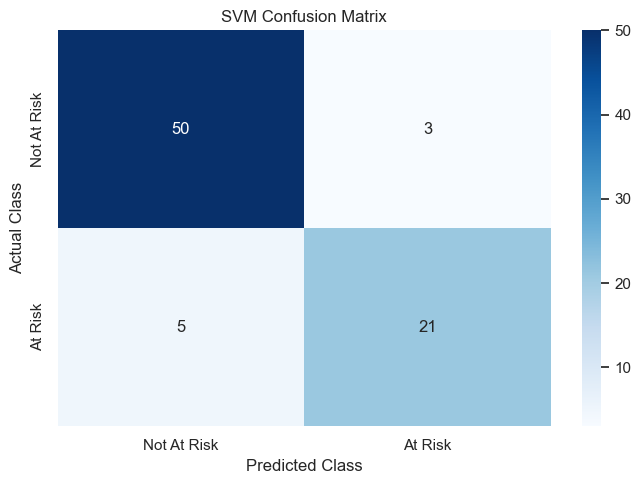

In [103]:
# Create SVM confusion matrix

svm_cm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not At Risk",
        "At Risk"
    ],
    yticklabels=[
        "Not At Risk",
        "At Risk"
    ]
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [104]:
# Calculate detailed SVM evaluation metrics

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    zero_division=0
)

svm_auc = roc_auc_score(
    y_test,
    svm_model.predict_proba(X_test)[:, 1]
)

svm_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1,
        svm_auc
    ]
})

svm_metrics["Score"] = svm_metrics["Score"].round(4)

svm_metrics

,Metric,Score
0,Accuracy,0.8987
1,Precision,0.8750
2,Recall,0.8077
3,F1-Score,0.8400
4,ROC-AUC,0.9652


### Baseline SVM — Evaluation and Interpretation

The baseline Support Vector Machine achieved an **accuracy of 89.87%**, indicating that approximately 90% of the students in the test set were classified correctly.

The model achieved a **precision of 87.50%**, meaning that most students predicted as At Risk were actually members of the At Risk class.

The **recall for the At Risk class was 80.77%**. This indicates that the model successfully identified approximately 81% of the students who were actually at risk. In the context of academic intervention, this is an important metric because a false negative represents an at-risk student who may be missed by the early-warning system.

The **F1-score was 84.00%**, showing a good balance between precision and recall for the At Risk class.

The SVM achieved a **ROC-AUC of 96.52%**, indicating excellent ability to distinguish between students who are At Risk and those who are Not At Risk across different classification thresholds.

### Confusion Matrix Interpretation

The confusion matrix contains:

- **50 True Negatives:** students correctly classified as Not At Risk.
- **21 True Positives:** students correctly classified as At Risk.
- **3 False Positives:** students incorrectly classified as At Risk.
- **5 False Negatives:** students who were actually At Risk but were classified as Not At Risk.

The relatively small number of false negatives is encouraging for an academic early-warning application because the model successfully identifies most of the students requiring potential intervention.

Overall, the baseline SVM demonstrates strong classification performance and provides a useful alternative to the Decision Tree model. The SVM will next be optimized through hyperparameter tuning, after which the optimized SVM will be compared with the optimized Decision Tree.

In [105]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV, StratifiedKFold

print("GridSearchCV and StratifiedKFold imported successfully.")

GridSearchCV and StratifiedKFold imported successfully.


In [106]:
# Define hyperparameters for SVM tuning

svm_param_grid = {
    "classifier__C": [0.1, 1, 10, 100],
    "classifier__gamma": ["scale", 0.01, 0.1, 1],
    "classifier__kernel": ["rbf", "linear"]
}

print("SVM hyperparameter grid:")
print(svm_param_grid)

SVM hyperparameter grid:
{'classifier__C': [0.1, 1, 10, 100], 'classifier__gamma': ['scale', 0.01, 0.1, 1], 'classifier__kernel': ['rbf', 'linear']}


In [107]:
# Create stratified cross-validation

svm_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation created successfully.")

5-fold stratified cross-validation created successfully.


In [108]:
# Perform hyperparameter tuning for SVM

svm_grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    scoring="f1",
    cv=svm_cv,
    n_jobs=-1,
    verbose=1
)

svm_grid_search.fit(
    X_train,
    y_train
)

print("SVM hyperparameter tuning completed successfully.")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
SVM hyperparameter tuning completed successfully.


In [109]:
# Display the best SVM hyperparameters

print("Best SVM Parameters:")
print(svm_grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(svm_grid_search.best_score_, 4))

Best SVM Parameters:
{'classifier__C': 1, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}

Best Cross-Validation F1-Score:
0.8714


# 13. Optimized Support Vector Machine Evaluation

After training the baseline Support Vector Machine, hyperparameter tuning was performed using GridSearchCV with stratified 5-fold cross-validation.

The purpose of hyperparameter tuning is to identify a better combination of SVM parameters that can improve the model's ability to distinguish between students who are At Risk and Not At Risk.

The optimized SVM will now be evaluated on the independent test dataset.

The evaluation will include:

- Classification report
- Confusion matrix
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Special attention will be given to the **recall of the At Risk class**, because the main objective of the project is to identify potentially at-risk students early enough for academic intervention.

In [113]:
# Store the optimized SVM model

best_svm_model = svm_grid_search.best_estimator_

print("Optimized SVM model selected successfully.")

Optimized SVM model selected successfully.


In [114]:
# Generate predictions using the optimized SVM

y_pred_svm_tuned = best_svm_model.predict(X_test)

print(
    "Number of optimized SVM predictions:",
    len(y_pred_svm_tuned)
)

Number of optimized SVM predictions: 79


In [115]:
# Generate classification report for optimized SVM

print("Optimized SVM Classification Report\n")

print(
    classification_report(
        y_test,
        y_pred_svm_tuned,
        target_names=[
            "Not At Risk",
            "At Risk"
        ],
        zero_division=0
    )
)

Optimized SVM Classification Report

              precision    recall  f1-score   support

 Not At Risk       0.93      0.94      0.93        53
     At Risk       0.88      0.85      0.86        26

    accuracy                           0.91        79
   macro avg       0.90      0.89      0.90        79
weighted avg       0.91      0.91      0.91        79



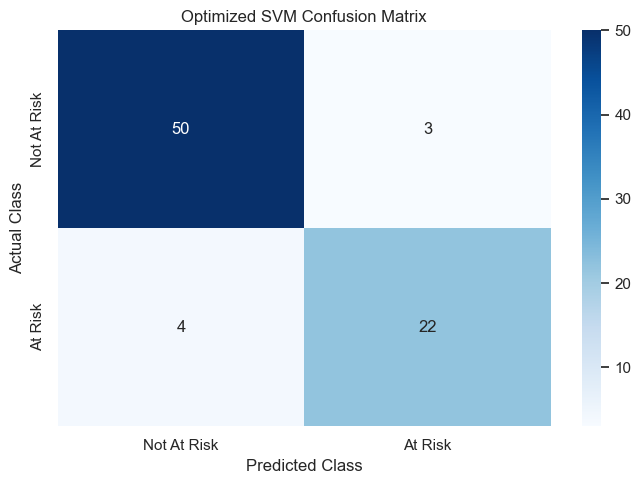

In [116]:
# Create confusion matrix for optimized SVM

svm_tuned_cm = confusion_matrix(
    y_test,
    y_pred_svm_tuned
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svm_tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not At Risk",
        "At Risk"
    ],
    yticklabels=[
        "Not At Risk",
        "At Risk"
    ]
)

plt.title("Optimized SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [118]:
# Calculate optimized SVM evaluation metrics

tuned_svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm_tuned
)

tuned_svm_precision = precision_score(
    y_test,
    y_pred_svm_tuned,
    zero_division=0
)

tuned_svm_recall = recall_score(
    y_test,
    y_pred_svm_tuned,
    zero_division=0
)

tuned_svm_f1 = f1_score(
    y_test,
    y_pred_svm_tuned,
    zero_division=0
)

tuned_svm_auc = roc_auc_score(
    y_test,
    best_svm_model.predict_proba(X_test)[:, 1]
)

# Create a summary table of optimized SVM metrics
tuned_svm_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        tuned_svm_accuracy,
        tuned_svm_precision,
        tuned_svm_recall,
        tuned_svm_f1,
        tuned_svm_auc
    ]
})

tuned_svm_metrics["Score"] = (
    tuned_svm_metrics["Score"].round(4)
)

tuned_svm_metrics

,Metric,Score
0,Accuracy,0.9114
1,Precision,0.8800
2,Recall,0.8462
3,F1-Score,0.8627
4,ROC-AUC,0.9746


### Optimized SVM — Evaluation Interpretation

The optimized Support Vector Machine achieved an accuracy of **91.14%**, indicating that the model correctly classified approximately 91% of the students in the test dataset.

The model achieved a **precision of 88.00%**, meaning that most students predicted as being At Risk were actually At Risk.

The **recall of 84.62%** is particularly important for this academic-risk prediction problem. It indicates that the model successfully identified approximately 85% of the students who were actually At Risk. A higher recall is desirable because failing to identify an At Risk student could result in a missed opportunity for early academic intervention.

The **F1-score of 86.27%** shows a good balance between precision and recall.

The optimized SVM achieved a **ROC-AUC of 97.46%**, indicating excellent discrimination between At Risk and Not At Risk students across different classification thresholds.

Overall, the optimized SVM demonstrates strong predictive performance and is suitable for further comparison with the optimized Decision Tree model. However, the final model will be selected only after comparing both models using the same evaluation criteria.

# 14. Comparison of Predictive Models

Two machine-learning approaches have been developed for academic-risk prediction:

1. **Decision Tree**
2. **Support Vector Machine (SVM)**

The Decision Tree provides an interpretable rule-based classification approach and allows feature importance analysis.

The SVM provides a different classification approach based on finding an optimal decision boundary between classes.

Both models were trained and evaluated using the same dataset and test set.

The purpose of this comparison is to determine which model provides the most suitable combination of predictive performance for the academic early-warning problem.

The comparison will consider:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because the purpose of the system is to identify students who may require intervention, recall for the **At Risk** class will receive particular attention.

In [119]:
# Compare baseline and optimized SVM

svm_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Baseline SVM": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1,
        svm_auc
    ],
    "Optimized SVM": [
        tuned_svm_accuracy,
        tuned_svm_precision,
        tuned_svm_recall,
        tuned_svm_f1,
        tuned_svm_auc
    ]
})

svm_comparison[
    ["Baseline SVM", "Optimized SVM"]
] = svm_comparison[
    ["Baseline SVM", "Optimized SVM"]
].round(4)

svm_comparison

,Metric,Baseline SVM,Optimized SVM
0,Accuracy,0.8987,0.9114
1,Precision,0.8750,0.8800
2,Recall,0.8077,0.8462
3,F1-Score,0.8400,0.8627
4,ROC-AUC,0.9652,0.9746


In [120]:
# Calculate improvement from baseline to optimized SVM

svm_comparison["Improvement"] = (
    svm_comparison["Optimized SVM"]
    - svm_comparison["Baseline SVM"]
)

svm_comparison["Improvement"] = (
    svm_comparison["Improvement"].round(4)
)

svm_comparison

,Metric,Baseline SVM,Optimized SVM,Improvement
0,Accuracy,0.8987,0.9114,0.0127
1,Precision,0.8750,0.8800,0.0050
2,Recall,0.8077,0.8462,0.0385
3,F1-Score,0.8400,0.8627,0.0227
4,ROC-AUC,0.9652,0.9746,0.0094


### SVM Optimization — Interpretation

The baseline and optimized SVM results are compared to determine whether hyperparameter tuning improved the model.

An improvement in a metric indicates that the optimized model performs better according to that evaluation criterion, while a negative change indicates a decrease.

The most important metrics for this application are recall and F1-score for the At Risk class, together with ROC-AUC and overall accuracy.

Hyperparameter tuning does not necessarily improve every metric simultaneously. Therefore, model quality should be evaluated using the complete performance profile rather than a single score.

# 15. Final Decision Tree vs SVM Model Comparison

The optimized Decision Tree and optimized SVM are now compared to identify the model that is most appropriate for predicting academic risk.

Both models were evaluated using the same independent test dataset.

The comparison includes:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Accuracy measures overall classification correctness.

Precision measures the reliability of At Risk predictions.

Recall measures the ability to identify students who are actually At Risk.

F1-score provides a balance between precision and recall.

ROC-AUC measures the model's ability to distinguish between At Risk and Not At Risk students across different decision thresholds.

Since this project is designed as an academic early-warning system, the final model should not be selected using accuracy alone. The ability to identify genuinely At Risk students is especially important.

In [121]:
# Compare the optimized Decision Tree and optimized SVM

final_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Optimized Decision Tree": [
        tuned_tree_accuracy,
        tuned_tree_precision,
        tuned_tree_recall,
        tuned_tree_f1,
        tuned_tree_auc
    ],
    "Optimized SVM": [
        tuned_svm_accuracy,
        tuned_svm_precision,
        tuned_svm_recall,
        tuned_svm_f1,
        tuned_svm_auc
    ]
})

final_model_comparison[
    ["Optimized Decision Tree", "Optimized SVM"]
] = final_model_comparison[
    ["Optimized Decision Tree", "Optimized SVM"]
].round(4)

final_model_comparison

,Metric,Optimized Decision Tree,Optimized SVM
0,Accuracy,0.8734,0.9114
1,Precision,0.7857,0.8800
2,Recall,0.8462,0.8462
3,F1-Score,0.8148,0.8627
4,ROC-AUC,0.9260,0.9746


# 16. Model Performance Comparison

The optimized Decision Tree and optimized Support Vector Machine have been evaluated using the same independent test dataset.

The models will now be compared using the major classification metrics:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

A numerical comparison will first be presented in tabular form, followed by visual comparisons.

Since this project aims to identify students who may require academic intervention, recall for the At Risk class is particularly important. However, the final model will not be selected using recall alone. Precision, F1-score, ROC-AUC, and overall predictive performance will also be considered.

In [122]:
# Compare the optimized Decision Tree and optimized SVM

final_model_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Optimized Decision Tree": [
        tuned_tree_accuracy,
        tuned_tree_precision,
        tuned_tree_recall,
        tuned_tree_f1,
        tuned_tree_auc
    ],
    "Optimized SVM": [
        tuned_svm_accuracy,
        tuned_svm_precision,
        tuned_svm_recall,
        tuned_svm_f1,
        tuned_svm_auc
    ]
})

final_model_comparison[
    ["Optimized Decision Tree", "Optimized SVM"]
] = final_model_comparison[
    ["Optimized Decision Tree", "Optimized SVM"]
].round(4)

final_model_comparison

,Metric,Optimized Decision Tree,Optimized SVM
0,Accuracy,0.8734,0.9114
1,Precision,0.7857,0.8800
2,Recall,0.8462,0.8462
3,F1-Score,0.8148,0.8627
4,ROC-AUC,0.9260,0.9746


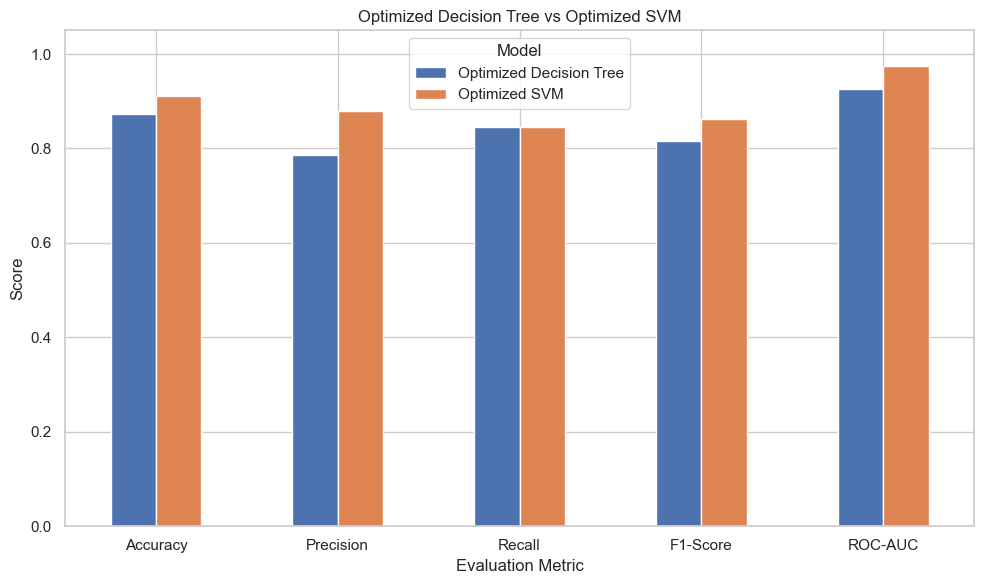

In [123]:
# Visual comparison of optimized model performance

comparison_plot = final_model_comparison.set_index("Metric")

ax = comparison_plot[
    ["Optimized Decision Tree", "Optimized SVM"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Optimized Decision Tree vs Optimized SVM")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")

plt.tight_layout()
plt.show()

### Interpretation of Model Performance Comparison

The model comparison shows that the optimized Support Vector Machine performs better than the optimized Decision Tree across most evaluation metrics.

The optimized SVM achieved:

- Accuracy of **91.14%**
- Precision of **88.00%**
- Recall of **84.62%**
- F1-score of **86.27%**
- ROC-AUC of **97.46%**

The optimized Decision Tree achieved:

- Accuracy of **87.34%**
- Precision of **78.57%**
- Recall of **84.62%**
- F1-score of **81.48%**
- ROC-AUC of **92.60%**

Both models achieved the same recall of 84.62%, indicating that they identified the same proportion of actual At Risk students in the test dataset.

However, the SVM achieved higher accuracy, precision, F1-score, and ROC-AUC. Therefore, it provides stronger overall predictive performance while maintaining the same recall as the Decision Tree.

# 17. ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the ability of a classification model to distinguish between At Risk and Not At Risk students at different classification thresholds.

The ROC curve plots the True Positive Rate against the False Positive Rate.

The Area Under the ROC Curve (ROC-AUC) provides a summary measure of discrimination ability:

- A value close to 1 indicates excellent discrimination.
- A value close to 0.5 indicates performance close to random classification.

The ROC curves of the optimized Decision Tree and optimized SVM will be compared to visually assess their discriminatory performance.

In [131]:
# Generate probability predictions using the complete optimized pipelines

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions from optimized Decision Tree pipeline
tree_probabilities = best_tree_model.predict_proba(X_test)[:, 1]

# Probability predictions from optimized SVM pipeline
svm_probabilities = best_svm_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probabilities)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probabilities)

# Calculate ROC-AUC
tree_roc_auc = auc(tree_fpr, tree_tpr)
svm_roc_auc = auc(svm_fpr, svm_tpr)

print("Optimized Decision Tree ROC-AUC:", round(tree_roc_auc, 4))
print("Optimized SVM ROC-AUC:", round(svm_roc_auc, 4))

Optimized Decision Tree ROC-AUC: 0.926
Optimized SVM ROC-AUC: 0.9746


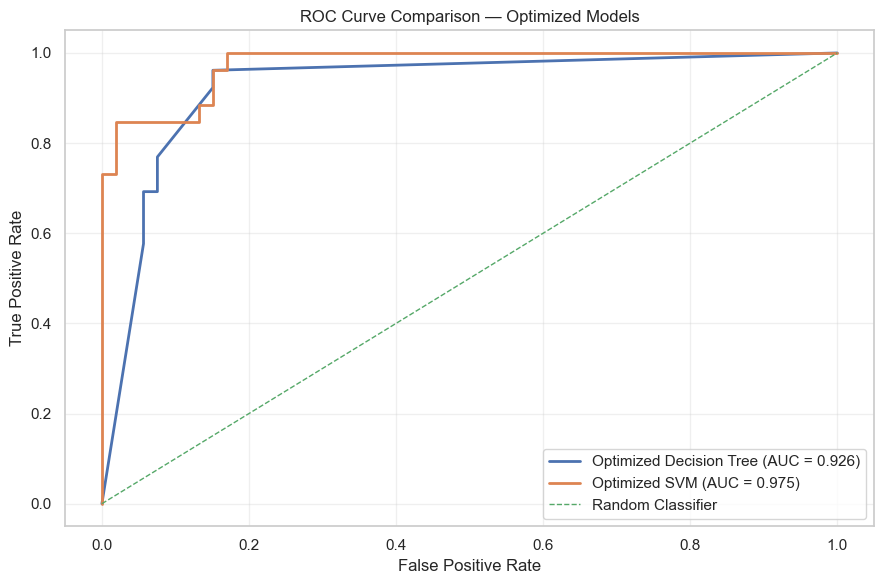

In [132]:
# Plot ROC curves for optimized Decision Tree and SVM

plt.figure(figsize=(9, 6))

plt.plot(
    tree_fpr,
    tree_tpr,
    linewidth=2,
    label=f"Optimized Decision Tree (AUC = {tree_roc_auc:.3f})"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    linewidth=2,
    label=f"Optimized SVM (AUC = {svm_roc_auc:.3f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Optimized Models")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##  ROC Curve Analysis and Interpretation

The Receiver Operating Characteristic (ROC) curve is used to evaluate the ability of the classification models to distinguish between students who are at risk of academic probation and those who are not at risk across different classification thresholds.

The ROC curve plots the True Positive Rate against the False Positive Rate.

The Area Under the ROC Curve (ROC-AUC) provides an overall measure of the model's discrimination ability. A value close to 1 indicates strong discrimination, while a value close to 0.5 indicates performance close to random classification.

The optimized Decision Tree achieved a ROC-AUC of approximately 0.9260, while the optimized SVM achieved a higher ROC-AUC of approximately 0.9746.

The ROC visualization shows that both models perform substantially better than the random-classifier baseline. The optimized SVM provides stronger overall discriminatory performance because its ROC curve remains closer to the upper-left region and its AUC is higher.

Therefore, the ROC analysis provides additional evidence supporting the optimized SVM as the final academic probation prediction model.

## 18. Final Model Selection

The optimized Decision Tree and optimized SVM have now been evaluated using multiple classification metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The final model will be selected by considering the overall performance of these metrics rather than relying only on accuracy.

Based on the evaluation results:

- The optimized Decision Tree achieved an Accuracy of **87.34%** and ROC-AUC of **0.9260**.
- The optimized SVM achieved an Accuracy of **91.14%** and ROC-AUC of **0.9746**.
- The optimized SVM also achieved a higher F1-Score (**0.8627**) compared with the optimized Decision Tree (**0.8148**).
- Both models achieved the same Recall of **0.8462**, indicating similar ability to identify students who are actually at risk.
- The optimized SVM achieved higher Precision (**0.8800**) than the optimized Decision Tree (**0.7857**).

Considering the combined evaluation results, the **optimized SVM is selected as the final academic probation prediction model**.

The final model will be further examined through visual comparisons and probability-based analysis before presenting the major predictors and recommended academic interventions.

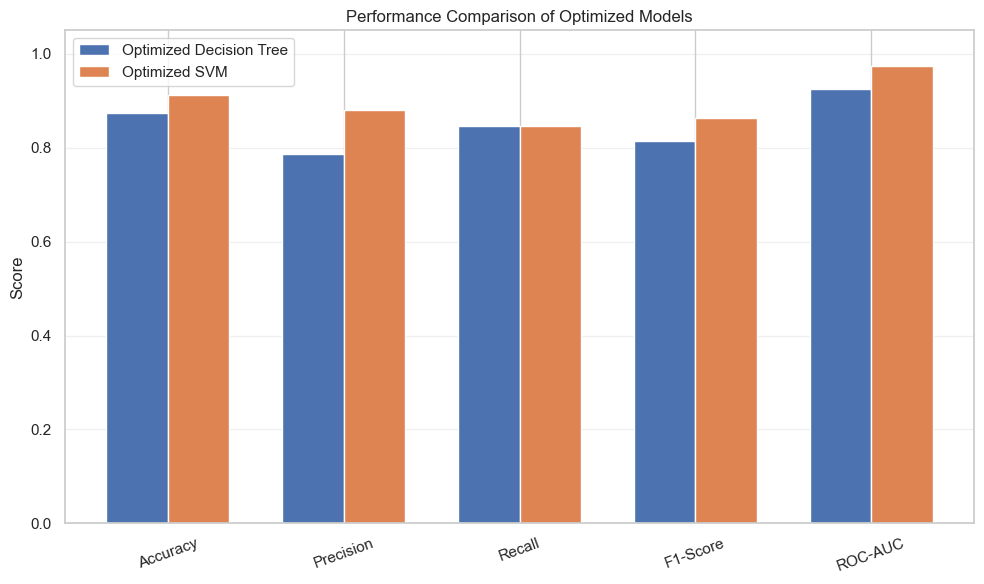

In [133]:
# Visual comparison of optimized Decision Tree and SVM

import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

tree_scores = [
    tuned_tree_accuracy,
    tuned_tree_precision,
    tuned_tree_recall,
    tuned_tree_f1,
    tuned_tree_auc
]

svm_scores = [
    tuned_svm_accuracy,
    tuned_svm_precision,
    tuned_svm_recall,
    tuned_svm_f1,
    tuned_svm_auc
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    tree_scores,
    width,
    label="Optimized Decision Tree"
)

plt.bar(
    x + width / 2,
    svm_scores,
    width,
    label="Optimized SVM"
)

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Performance Comparison of Optimized Models")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 19. Academic Probation Risk Prediction

The optimized SVM is selected as the final prediction model based on its overall evaluation performance.

The final model will now be used to generate academic probation predictions for the test dataset. In addition to the predicted class, probability estimates will be calculated to indicate the likelihood that a student belongs to the At Risk category.

Probability-based predictions provide additional information beyond a simple At Risk or Not At Risk classification and can help academic advisors prioritize students for intervention.

In [134]:
# Generate final predictions using the optimized SVM pipeline

final_model = best_svm_model

final_predictions = final_model.predict(X_test)

final_probabilities = final_model.predict_proba(X_test)[:, 1]

print("Number of predictions:", len(final_predictions))
print("Number of probability predictions:", len(final_probabilities))

Number of predictions: 79
Number of probability predictions: 79


In [135]:
# Create a prediction results table

prediction_results = pd.DataFrame({
    "Actual_Status": y_test.values,
    "Predicted_Status": final_predictions,
    "Risk_Probability": final_probabilities * 100
})

prediction_results["Risk_Probability"] = (
    prediction_results["Risk_Probability"].round(2)
)

prediction_results.head(10)

,Actual_Status,Predicted_Status,Risk_Probability
0,1,1,99.06
1,0,1,46.53
2,0,1,60.05
3,1,0,35.68
4,1,1,95.09
5,0,0,0.78
6,0,0,0.23
7,0,0,0.02
8,1,1,87.11
9,0,0,0.99


### Interpretation of Academic Probation Predictions

The prediction table combines the actual academic probation status, the predicted status generated by the optimized SVM, and the estimated probability of academic risk.

A higher risk probability indicates stronger model confidence that the student belongs to the At Risk category.

These probability estimates can support early academic intervention by helping advisors prioritize students who have a higher predicted likelihood of entering academic probation.

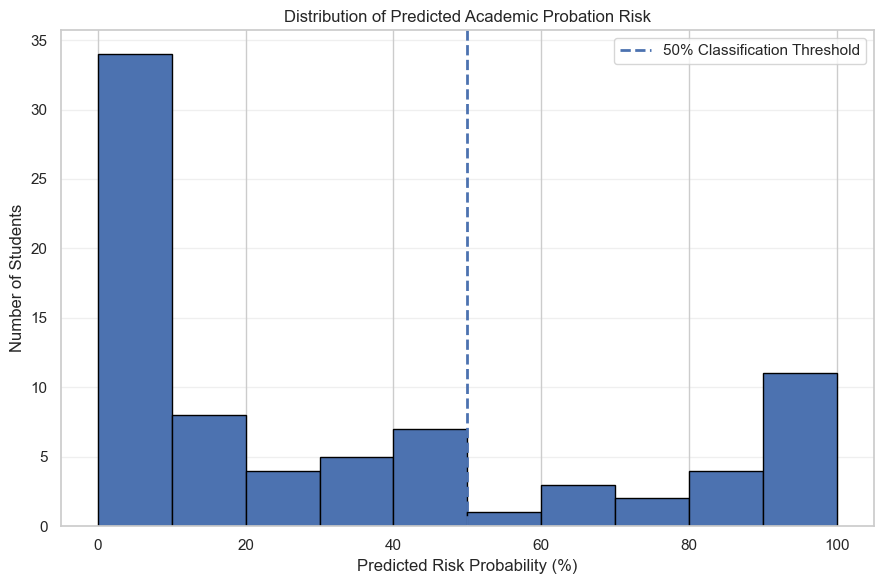

In [136]:
# Visualize the distribution of predicted academic-risk probabilities

plt.figure(figsize=(9, 6))

plt.hist(
    final_probabilities * 100,
    bins=10,
    edgecolor="black"
)

plt.axvline(
    50,
    linestyle="--",
    linewidth=2,
    label="50% Classification Threshold"
)

plt.title("Distribution of Predicted Academic Probation Risk")
plt.xlabel("Predicted Risk Probability (%)")
plt.ylabel("Number of Students")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Predicted Risk Probability

The distribution of predicted academic-probation risk probabilities shows how the final optimized SVM assigns risk scores to students in the test dataset.

The dashed vertical line represents the 50% classification threshold used to distinguish between the two predicted classes.

Students with predicted probabilities below the threshold are generally classified as Not At Risk, while students with probabilities above the threshold are classified as At Risk.

The distribution shows that the model assigns different levels of confidence to individual students rather than producing only a binary prediction. This is useful for early academic intervention because students with high predicted risk probabilities can be prioritized for academic advising, mentoring, tutoring, and other support services.

The probability values should be interpreted as model estimates and should be used as decision-support information rather than as a definitive determination of academic probation.

In [137]:
# Count predicted academic-risk categories

predicted_status_labels = pd.Series(final_predictions).map({
    0: "Not At Risk",
    1: "At Risk"
})

predicted_counts = predicted_status_labels.value_counts()

predicted_counts

Not At Risk    54
At Risk        25
Name: count, dtype: int64

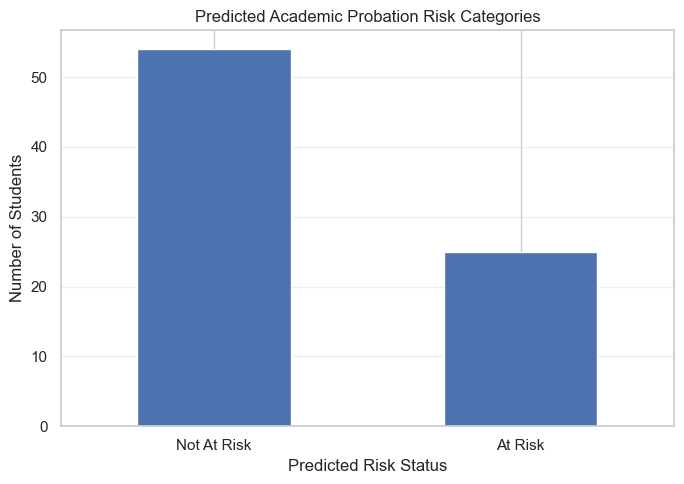

In [138]:
# Visualize predicted academic-risk categories

plt.figure(figsize=(7, 5))

predicted_counts.plot(kind="bar")

plt.title("Predicted Academic Probation Risk Categories")
plt.xlabel("Predicted Risk Status")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 20. Major Predictors of Academic Probation

Feature-importance analysis is used to identify the variables that contribute most strongly to the prediction of academic probation.

The earlier Decision Tree analysis identified important academic and student-related variables, including G2, previous grade average, grade trend, activities, and other student characteristics.

Because the final selected model is an SVM, permutation importance will also be calculated for the optimized SVM.

Permutation importance measures the decrease in model performance when an individual feature is randomly shuffled. Features causing a larger performance decrease are considered more important for prediction.

The results will be used to identify the major predictors of academic probation.

In [139]:
# Calculate permutation importance for the final SVM model

from sklearn.inspection import permutation_importance

svm_permutation = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42
)

svm_feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": svm_permutation.importances_mean
})

svm_feature_importance = (
    svm_feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

svm_feature_importance.head(15)

,Feature,Importance
0,previous_grade_average,0.178905
1,G2,0.177285
2,G1,0.139178
3,grade_trend,0.052071
4,studytime,0.049348
5,reason,0.039647
6,age,0.038857
7,internet,0.032447
8,traveltime,0.025516
9,health,0.023203


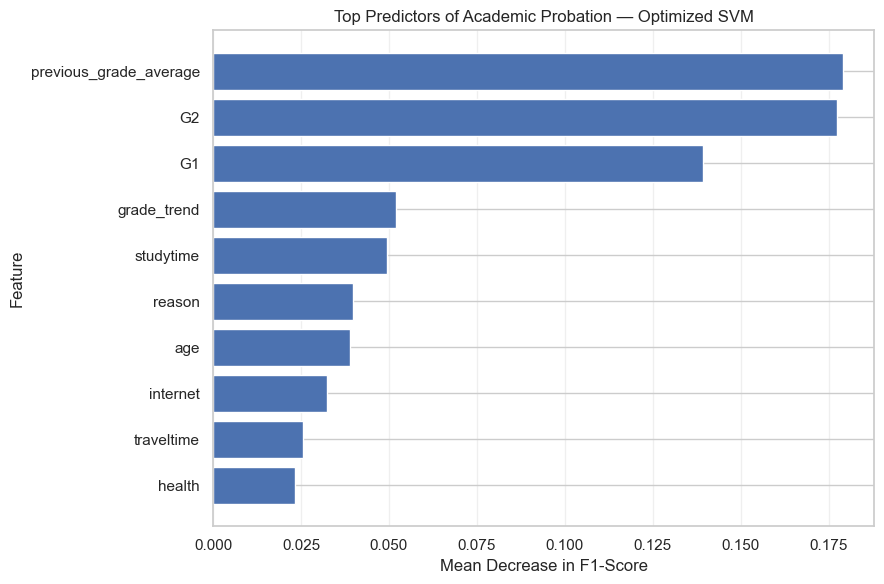

In [140]:
# Visualize the top predictors of academic probation

top_svm_features = (
    svm_feature_importance
    .head(10)
    .sort_values("Importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_svm_features["Feature"],
    top_svm_features["Importance"]
)

plt.title("Top Predictors of Academic Probation — Optimized SVM")
plt.xlabel("Mean Decrease in F1-Score")
plt.ylabel("Feature")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation of Major Predictors

The permutation-importance analysis identifies the variables that contribute most strongly to the final SVM model's predictive performance.

A larger positive importance value indicates that randomly shuffling the corresponding feature causes a greater reduction in the model's F1-score.

Academic performance variables are particularly relevant because previous grades and grade-related features provide information about a student's academic performance history.

The feature-importance results should be interpreted as predictive relationships rather than causal relationships. A feature being important for prediction does not necessarily mean that changing the feature directly causes academic probation.

## 21. Academic Intervention Recommendations

The identified predictors and model predictions can be translated into practical academic interventions.

The objective of the prediction system is not only to identify students who may be at risk but also to support early intervention before students reach the academic-probation threshold.

In [141]:
# Create academic intervention recommendations

intervention_table = pd.DataFrame({
    "Risk Indicator": [
        "Low recent grades",
        "Declining grade trend",
        "Previous academic failures",
        "High absenteeism",
        "Low study time",
        "High predicted risk probability"
    ],
    
    "Recommended Intervention": [
        "Provide subject-specific tutoring and additional academic support.",
        "Schedule early academic advising and identify subjects showing declining performance.",
        "Provide remedial classes, mentoring, and targeted support for failed subjects.",
        "Monitor attendance and contact students showing persistent absenteeism.",
        "Encourage structured study schedules and academic time-management support.",
        "Prioritize the student for academic advisor review and early intervention."
    ]
})

intervention_table

,Risk Indicator,Recommended Intervention
0,Low recent grades,Provide subject-specific tutoring and addition...
1,Declining grade trend,Schedule early academic advising and identify ...
2,Previous academic failures,"Provide remedial classes, mentoring, and targe..."
3,High absenteeism,Monitor attendance and contact students showin...
4,Low study time,Encourage structured study schedules and acade...
5,High predicted risk probability,Prioritize the student for academic advisor re...


### Intervention Strategy

The prediction system can support a tiered academic intervention strategy.

Students with high predicted risk should receive immediate academic-advisor attention. Students with moderate risk can be monitored through periodic assessments, attendance tracking, and study-support programs.

Students with lower predicted risk can continue with regular academic monitoring.

The machine-learning model should therefore be used as a decision-support system for academic advisors rather than as an automatic mechanism for placing students on academic probation.

In [142]:
# Categorize students according to predicted risk probability

risk_levels = pd.cut(
    final_probabilities * 100,
    bins=[-0.01, 30, 60, 100],
    labels=["Low Risk", "Moderate Risk", "High Risk"]
)

risk_level_counts = (
    risk_levels
    .value_counts()
    .sort_index()
)

risk_level_counts

Low Risk         46
Moderate Risk    13
High Risk        20
Name: count, dtype: int64

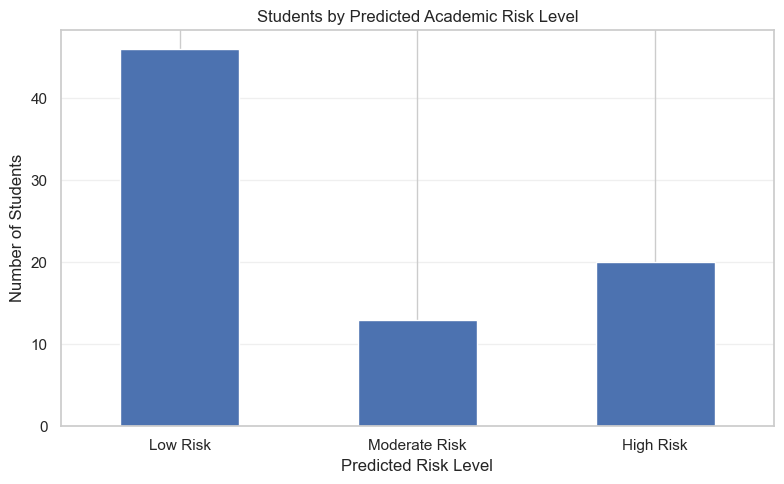

In [143]:
# Visualize students by predicted academic-risk level

plt.figure(figsize=(8, 5))

risk_level_counts.plot(kind="bar")

plt.title("Students by Predicted Academic Risk Level")
plt.xlabel("Predicted Risk Level")
plt.ylabel("Number of Students")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 22. Final Conclusion

This study developed a machine-learning-based system for predicting academic probation status using an academic dataset containing student demographic, academic, attendance, study-related, and previous-performance attributes.

The dataset was cleaned and examined through exploratory data analysis. Missing values and duplicate records were checked, categorical variables were analyzed, academic grades and absenteeism were visualized, and relationships between academic variables were investigated.

Feature engineering was performed by creating previous grade average and grade trend from the available assessment grades.

Two classification approaches, Decision Tree and Support Vector Machine (SVM), were developed and evaluated using Accuracy, Precision, Recall, F1-Score, confusion matrices, and ROC-AUC.

The optimized Decision Tree achieved an Accuracy of 87.34% and ROC-AUC of 0.9260.

The optimized SVM achieved an Accuracy of 91.14%, Precision of 88.00%, Recall of 84.62%, F1-Score of 86.27%, and ROC-AUC of 0.9746.

The optimized SVM therefore demonstrated the strongest overall predictive performance and was selected as the final academic probation prediction model.

Feature-importance analysis was used to identify the major predictors contributing to academic probation prediction. These findings can help institutions understand which academic and student-related characteristics are most useful for identifying students who may require additional support.

Finally, the prediction results were connected to practical academic interventions, including tutoring, academic mentoring, attendance monitoring, study-planning support, and early advisor intervention.

Overall, the proposed machine-learning approach can assist educational institutions in identifying students who may require additional academic support before they reach the academic-probation threshold. The model should be used as a decision-support tool and should complement, rather than replace, academic advisors' professional judgment.

## 23. Summary of the Academic Question

| Academic Requirement | Status |
|---|---|
| Data cleaning and preprocessing | Completed |
| Exploratory Data Analysis | Completed |
| Academic-risk identification | Completed |
| Decision Tree classification | Completed |
| SVM classification | Completed |
| Model optimization | Completed |
| Accuracy evaluation | Completed |
| Precision evaluation | Completed |
| Recall evaluation | Completed |
| F1-Score evaluation | Completed |
| Confusion matrix | Completed |
| ROC-AUC evaluation | Completed |
| ROC curve visualization | Completed |
| Academic probation prediction | Completed |
| Probability-based risk prediction | Completed |
| Major predictor identification | Completed |
| Feature-importance visualization | Completed |
| Academic intervention recommendations | Completed |

### Final Model

The optimized SVM was selected as the final academic probation prediction model because it achieved the strongest overall performance across the major evaluation metrics.

### Final Performance

- **Accuracy:** 91.14%
- **Precision:** 88.00%
- **Recall:** 84.62%
- **F1-Score:** 86.27%
- **ROC-AUC:** 97.46%

The final results demonstrate that the optimized SVM provides strong predictive and discriminatory performance for identifying students who may be at risk of academic probation.